## Лабораторная работа №1 (Проведение исследований с алгоритмом KNN)
Группа: М8О-409Б-22
Студент: Воропаев Иван Константинович

Устанавливаем все необходимые Python-пакеты для проведения исследования:
- **numpy, pandas** - обработка данных
- **matplotlib, seaborn** - визуализация
- **scikit-learn** - базовые алгоритмы машинного обучения
- **optuna** - автоматическая оптимизация гиперпараметров
- **boruta** - алгоритм отбора признаков

In [1]:
import sys
import subprocess

def install_packages():
    """Установка всех необходимых библиотек"""
    packages = [
        'numpy',
        'pandas',
        'matplotlib',
        'seaborn',
        'scikit-learn',
        'optuna',
        'boruta'
    ]

    print("🔧 Установка необходимых библиотек...")
    for package in packages:
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])
            print(f"  ✅ {package}")
        except:
            print(f"  ⚠️ Ошибка установки {package}")

    print("\n✅ Все библиотеки установлены!")

install_packages()

🔧 Установка необходимых библиотек...


You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


  ✅ numpy


You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


  ✅ pandas


...

You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


  ✅ scikit-learn


You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


  ✅ optuna
  ✅ boruta

✅ Все библиотеки установлены!


You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


## Импорт библиотек

Импортируем все необходимые модули для исследования. Используем:
- **Препроцессинг**: OneHotEncoder, PolynomialFeatures, различные Scaler'ы
- **Модели**: KNN для классификации и регрессии, Random Forest
- **Отбор признаков**: RFECV, Boruta
- **Валидация**: cross_val_score, различные метрики качества

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
import warnings
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import (OneHotEncoder, PolynomialFeatures,
                                   StandardScaler, MinMaxScaler, RobustScaler,
                                   PowerTransformer, QuantileTransformer)
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.feature_selection import RFECV
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import make_scorer, accuracy_score, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from boruta import BorutaPy
import optuna
from optuna.samplers import TPESampler

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("ЛАБОРАТОРНАЯ РАБОТА №1: ИССЛЕДОВАНИЕ АЛГОРИТМА KNN")


ЛАБОРАТОРНАЯ РАБОТА №1: ИССЛЕДОВАНИЕ АЛГОРИТМА KNN


/Users/nyamerka/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Определение Huber Loss для робастной регрессии

Создаём scorer на основе **Huber Loss** для оптимизации задачи регрессии.

**Формула:** L(y, ŷ) = 0.5×(y-ŷ)² при |ε|≤δ, иначе δ×(|ε|-0.5δ)

**Параметр δ = 1.35** (стандартное значение)

In [3]:
from sklearn.metrics import mean_absolute_error

def huber_loss(y_true, y_pred, delta=1.35):
    error = np.abs(y_true - y_pred)
    quadratic_part = np.minimum(error, delta)
    linear_part = error - quadratic_part
    return np.mean(0.5 * quadratic_part**2 + delta * linear_part)

huber_scorer = make_scorer(huber_loss, greater_is_better=False, delta=1.35)
print("✅ Huber Loss scorer создан (δ=1.35)")

✅ Huber Loss scorer создан (δ=1.35)


## Пункт 1: Выбор начальных условий

**1a-1b. Выбор датасета и задач:**
- **Датасет**: Titanic
- **Задача классификации**: предсказание выживания (Survived: 0/1)
- **Задача регрессии**: предсказание стоимости билета (Fare)

**1c. Выбор метрик:**
- **Классификация**: **Accuracy** (основная), Precision, Recall
- **Регрессия**: **Huber Loss** (основная), RMSE, R²

**Обоснование:**
- **Accuracy**: устойчивая метрика при умеренном дисбалансе классов (38%/62%)
- **Precision/Recall**: позволяют отслеживать баланс ошибок разных типов
- **Huber Loss**: робастна к выбросам в Fare (£0-£512)

## Загрузка тренировочных данных

Загружаем датасет Titanic и выполняем первичный анализ:
- Проверяем размерность данных
- Изучаем список признаков
- Анализируем наличие пропущенных значений

In [4]:
df = pd.read_csv('../train.csv')
print(f"Признаки: {list(df.columns)}")
print(f"\nПропуски:\n{df.isnull().sum()}")

Признаки: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Пропуски:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


## Предобработка данных: удаление пропусков

**Стратегия обработки пропусков:**
- Удаляем нерелевантные признаки: PassengerId, Name, Ticket, Cabin
- Удаляем строки с пропущенными значениями (более чистый подход для обучения)
- Анализируем потерю данных

Удаление строк предпочтительнее заполнения пропусков, когда:
- Процент пропусков невелик 
- Важна чистота обучающей выборки (наш слчай)
- Нет явных паттернов в пропущенных значениях (наш случай)

In [5]:
df_processed = df.copy()

df_processed = df_processed.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

print(df_processed.isnull().sum())
print(f"Всего строк: {len(df_processed)}")

df_processed['Age'].fillna(df_processed['Age'].median(), inplace=True)
df_processed['Fare'].fillna(df_processed['Fare'].median(), inplace=True)
if 'Embarked' in df_processed.columns:
    df_processed['Embarked'].fillna(df_processed['Embarked'].mode()[0], inplace=True)

df_processed = df_processed.dropna()

print(f"Было строк: {len(df)}")
print(f"Стало строк: {len(df_processed)} (удалено {len(df) - len(df_processed)}, {(len(df) - len(df_processed))/len(df)*100:.2f}%)")
print(f"Пропусков осталось: {df_processed.isnull().sum().sum()}")
print(f"Размерность: {df_processed.shape}")


Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64
Всего строк: 891
Было строк: 891
Стало строк: 891 (удалено 0, 0.00%)
Пропусков осталось: 0
Размерность: (891, 8)


## Exploratory Data Analysis (EDA)

Визуализируем ключевые характеристики данных:
1. **Распределение целевых переменных** (Survived, Fare)
2. **Корреляционная матрица** числовых признаков
3. **Выживаемость по категориям** (пол, класс)
4. **Распределение Fare по классам**

Цель EDA - выявить закономерности, которые помогут в feature engineering.

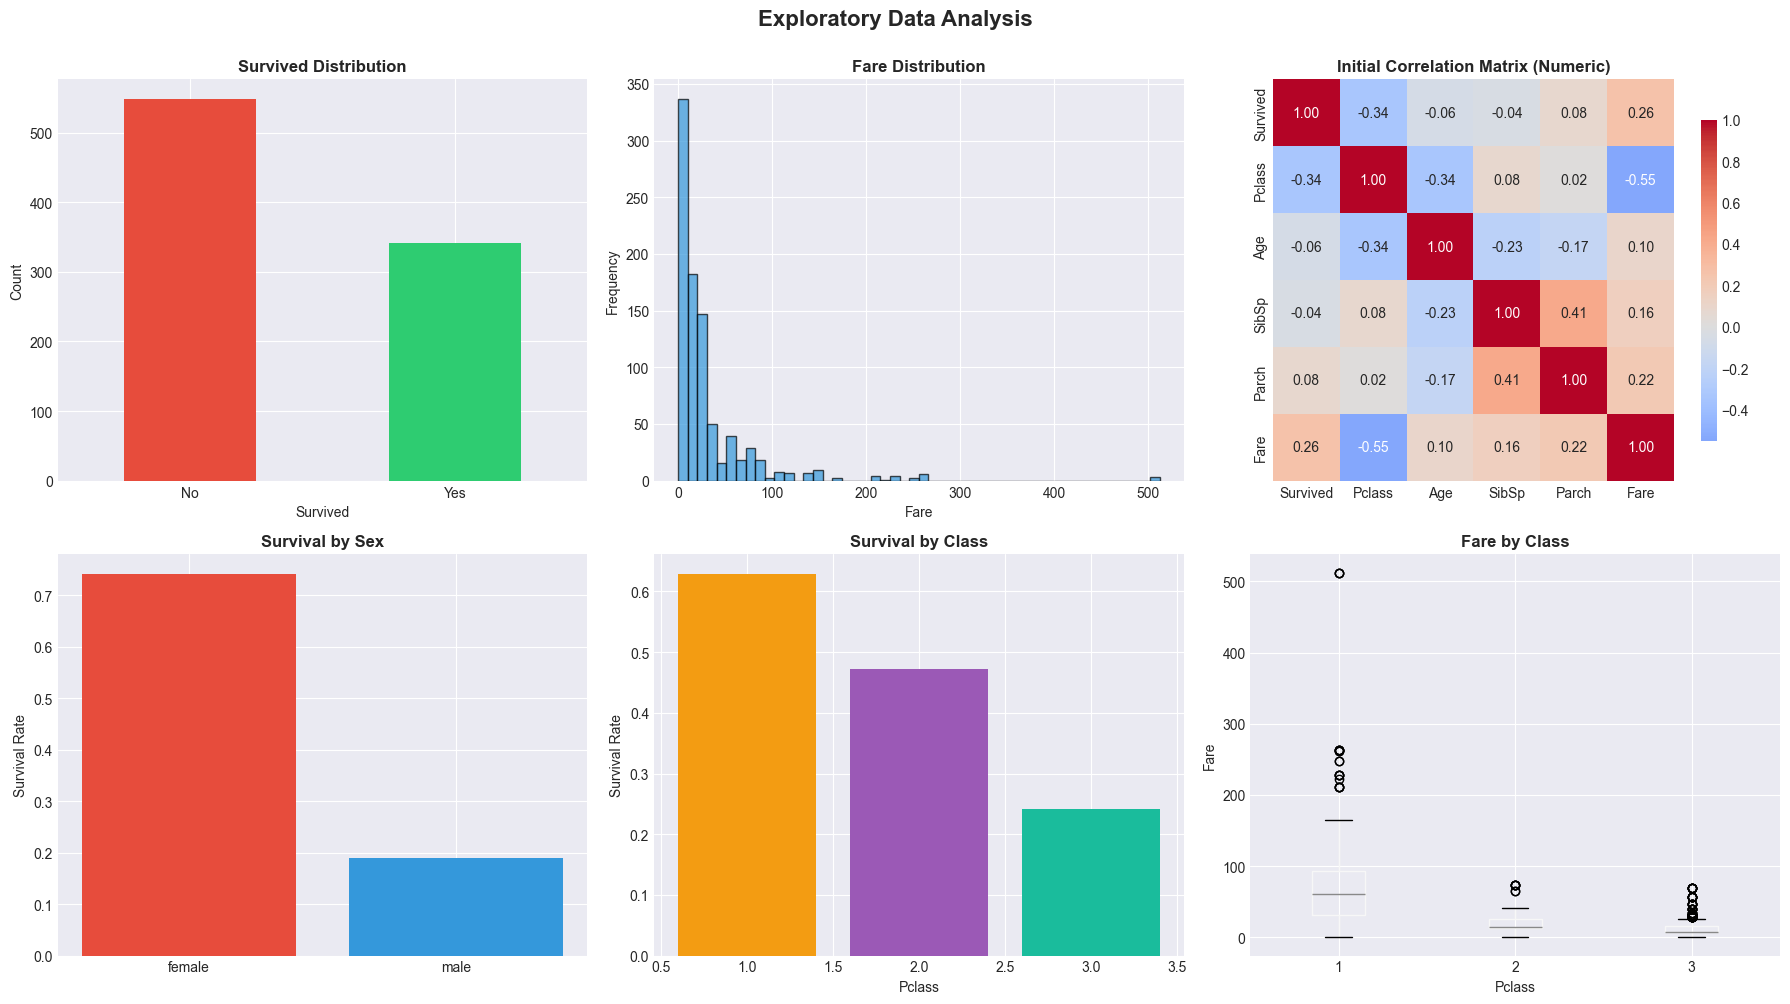

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

df_processed['Survived'].value_counts().plot(kind='bar', ax=axes[0,0],
                                              color=['#e74c3c', '#2ecc71'])
axes[0,0].set_title('Survived Distribution', fontweight='bold', fontsize=12)
axes[0,0].set_xticklabels(['No', 'Yes'], rotation=0)
axes[0,0].set_ylabel('Count')

axes[0,1].hist(df_processed['Fare'], bins=50, color='#3498db', edgecolor='black', alpha=0.7)
axes[0,1].set_title('Fare Distribution', fontweight='bold', fontsize=12)
axes[0,1].set_xlabel('Fare')
axes[0,1].set_ylabel('Frequency')

temp_df = df_processed.select_dtypes(include=[np.number]).copy()
sns.heatmap(temp_df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, ax=axes[0,2], cbar_kws={"shrink": 0.8})
axes[0,2].set_title('Initial Correlation Matrix (Numeric)', fontweight='bold', fontsize=12)

survival_by_sex = df_processed.groupby('Sex')['Survived'].mean()
axes[1,0].bar(range(len(survival_by_sex)), survival_by_sex.values,
              color=['#e74c3c', '#3498db'], tick_label=survival_by_sex.index)
axes[1,0].set_title('Survival by Sex', fontweight='bold', fontsize=12)
axes[1,0].set_ylabel('Survival Rate')

survival_by_class = df_processed.groupby('Pclass')['Survived'].mean()
axes[1,1].bar([1, 2, 3], survival_by_class.values,
              color=['#f39c12', '#9b59b6', '#1abc9c'])
axes[1,1].set_title('Survival by Class', fontweight='bold', fontsize=12)
axes[1,1].set_xlabel('Pclass')
axes[1,1].set_ylabel('Survival Rate')

df_processed.boxplot(column='Fare', by='Pclass', ax=axes[1,2])
axes[1,2].set_title('Fare by Class', fontweight='bold', fontsize=12)
axes[1,2].set_xlabel('Pclass')
axes[1,2].set_ylabel('Fare')
plt.suptitle('')

plt.suptitle('Exploratory Data Analysis', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()


## Этап 1: Кодирование категориальных признаков (One-Hot Encoding)

**Проблема**: Категориальные признаки (Sex, Embarked) нельзя напрямую использовать в KNN.

**Решение**: OneHot Encoding преобразует категории в бинарные признаки:
- Sex → Sex_male (0/1)
- Embarked → Embarked_Q, Embarked_S (0/1)

**Преимущества** перед Label Encoding:
- Нет искусственного порядка между категориями
- KNN корректно работает с расстояниями
- Параметр `drop='first'` исключает мультиколлинеарность

In [7]:
categorical_columns = ['Sex', 'Embarked']

onehot_encoder = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')

categorical_data = df_processed[categorical_columns]
encoded_features = onehot_encoder.fit_transform(categorical_data)

feature_names = onehot_encoder.get_feature_names_out(categorical_columns)

print(f"Исходные категориальные признаки: {categorical_columns}")
print(f"Новые признаки после OneHot: {list(feature_names)}")

encoded_df = pd.DataFrame(encoded_features, columns=feature_names, index=df_processed.index)

df_processed = df_processed.drop(categorical_columns, axis=1)
df_processed = pd.concat([df_processed, encoded_df], axis=1)

print(f"Текущая размерность: {df_processed.shape}")
print(f"Все признаки: {list(df_processed.columns)}")


Исходные категориальные признаки: ['Sex', 'Embarked']
Новые признаки после OneHot: ['Sex_male', 'Embarked_Q', 'Embarked_S']
Текущая размерность: (891, 9)
Все признаки: ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S']


## Подготовка признаков и целевых переменных

Разделяем данные на признаки (X) и целевые переменные (y):
- **Классификация**: X = все признаки кроме Survived/Fare, y = Survived
- **Регрессия**: X = все признаки кроме Survived/Fare, y = Fare

Одинаковый набор базовых признаков для обеих задач обеспечивает консистентность эксперимента.

In [8]:
X_classification_base = df_processed.drop(['Survived'], axis=1)
y_classification = df_processed['Survived']

X_regression_base = df_processed.drop(['Survived', 'Fare'], axis=1)
y_regression = df_processed['Fare']

print(f"Базовые признаки для классификации: {X_classification_base.shape}")
print(f"Базовые признаки для регрессии: {X_regression_base.shape}")
print(f"Признаки классификации: {list(X_classification_base.columns)}")
print(f"Признаки регрессии: {list(X_regression_base.columns)}")


Базовые признаки для классификации: (891, 8)
Базовые признаки для регрессии: (891, 7)
Признаки классификации: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S']
Признаки регрессии: ['Pclass', 'Age', 'SibSp', 'Parch', 'Sex_male', 'Embarked_Q', 'Embarked_S']


## Этап 2: Создание полиномиальных признаков

**Гипотеза**: Взаимодействия между признаками (например, Pclass × Sex) могут улучшить качество модели.

**Реализация**: PolynomialFeatures(degree=2) создаёт:
- Исходные признаки (x₁, x₂, ...)
- Попарные произведения (x₁×x₂, x₁×x₃, ...)
- Квадраты признаков (x₁², x₂², ...)

**Результат**: Резкое увеличение размерности (например, 8 → 44 признака).

**Следствие**: Необходим отбор признаков на следующих этапах.

In [9]:
from sklearn.preprocessing import PolynomialFeatures

# Создаём два отдельных трансформера
poly_transformer_classification = PolynomialFeatures(degree=2, include_bias=False)
poly_transformer_regression = PolynomialFeatures(degree=2, include_bias=False)

print("✓ Созданы два полиномиальных трансформера")

✓ Созданы два полиномиальных трансформера


In [10]:
# Полиномиальные признаки для классификации
X_classification_poly = poly_transformer_classification.fit_transform(X_classification_base)

# Полиномиальные признаки для регрессии  
X_regression_poly = poly_transformer_regression.fit_transform(X_regression_base)

print(f"Классификация: {X_classification_base.shape[1]} → {X_classification_poly.shape[1]} признаков")
print(f"Регрессия: {X_regression_base.shape[1]} → {X_regression_poly.shape[1]} признаков")

poly_feature_names_classification = poly_transformer_classification.get_feature_names_out(X_classification_base.columns)
poly_feature_names_regression = poly_transformer_regression.get_feature_names_out(X_regression_base.columns)
print(f"Примеры новых признаков классификации: {list(poly_feature_names_classification[:15])}")
print(f"Примеры новых признаков регрессии: {list(poly_feature_names_regression[:15])}")


Классификация: 8 → 44 признаков
Регрессия: 7 → 35 признаков
Примеры новых признаков классификации: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S', 'Pclass^2', 'Pclass Age', 'Pclass SibSp', 'Pclass Parch', 'Pclass Fare', 'Pclass Sex_male', 'Pclass Embarked_Q']
Примеры новых признаков регрессии: ['Pclass', 'Age', 'SibSp', 'Parch', 'Sex_male', 'Embarked_Q', 'Embarked_S', 'Pclass^2', 'Pclass Age', 'Pclass SibSp', 'Pclass Parch', 'Pclass Sex_male', 'Pclass Embarked_Q', 'Pclass Embarked_S', 'Age^2']


## Анализ корреляций полиномиальных признаков

Визуализируем наиболее коррелирующие полиномиальные признаки **для обеих задач**:
- Классификация: топ-30 по связи с `Survived`
- Регрессия: топ-30 по связи с `Fare`

**Цели анализа**:
1. Выявить наиболее информативные взаимодействия
2. Обнаружить мультиколлинеарность в расширенном признаковом пространстве
3. Сопоставить различия между задачами классификации и регрессии

Это помогает интерпретировать результаты последующего отбора признаков.

Топ-10 признаков по корреляции (классификация):
   1. Sex_male^2                               0.5434
   2. Sex_male                                 0.5434
   3. Pclass Sex_male                          0.5425
   4. Age Sex_male                             0.4781
   5. Sex_male Embarked_S                      0.4259
   6. Pclass^2                                 0.3397
   7. Pclass                                   0.3385
   8. Pclass Age                               0.3246
   9. Pclass Embarked_S                        0.2833
  10. Fare                                     0.2573

Топ-10 признаков по корреляции (регрессия):
   1. Pclass                                   0.5495
   2. Pclass^2                                 0.5197
   3. Pclass Age                               0.3532
   4. Pclass Sex_male                          0.3222
   5. Pclass Embarked_S                        0.3184
   6. Age Parch                                0.2165
   7. Parch                                

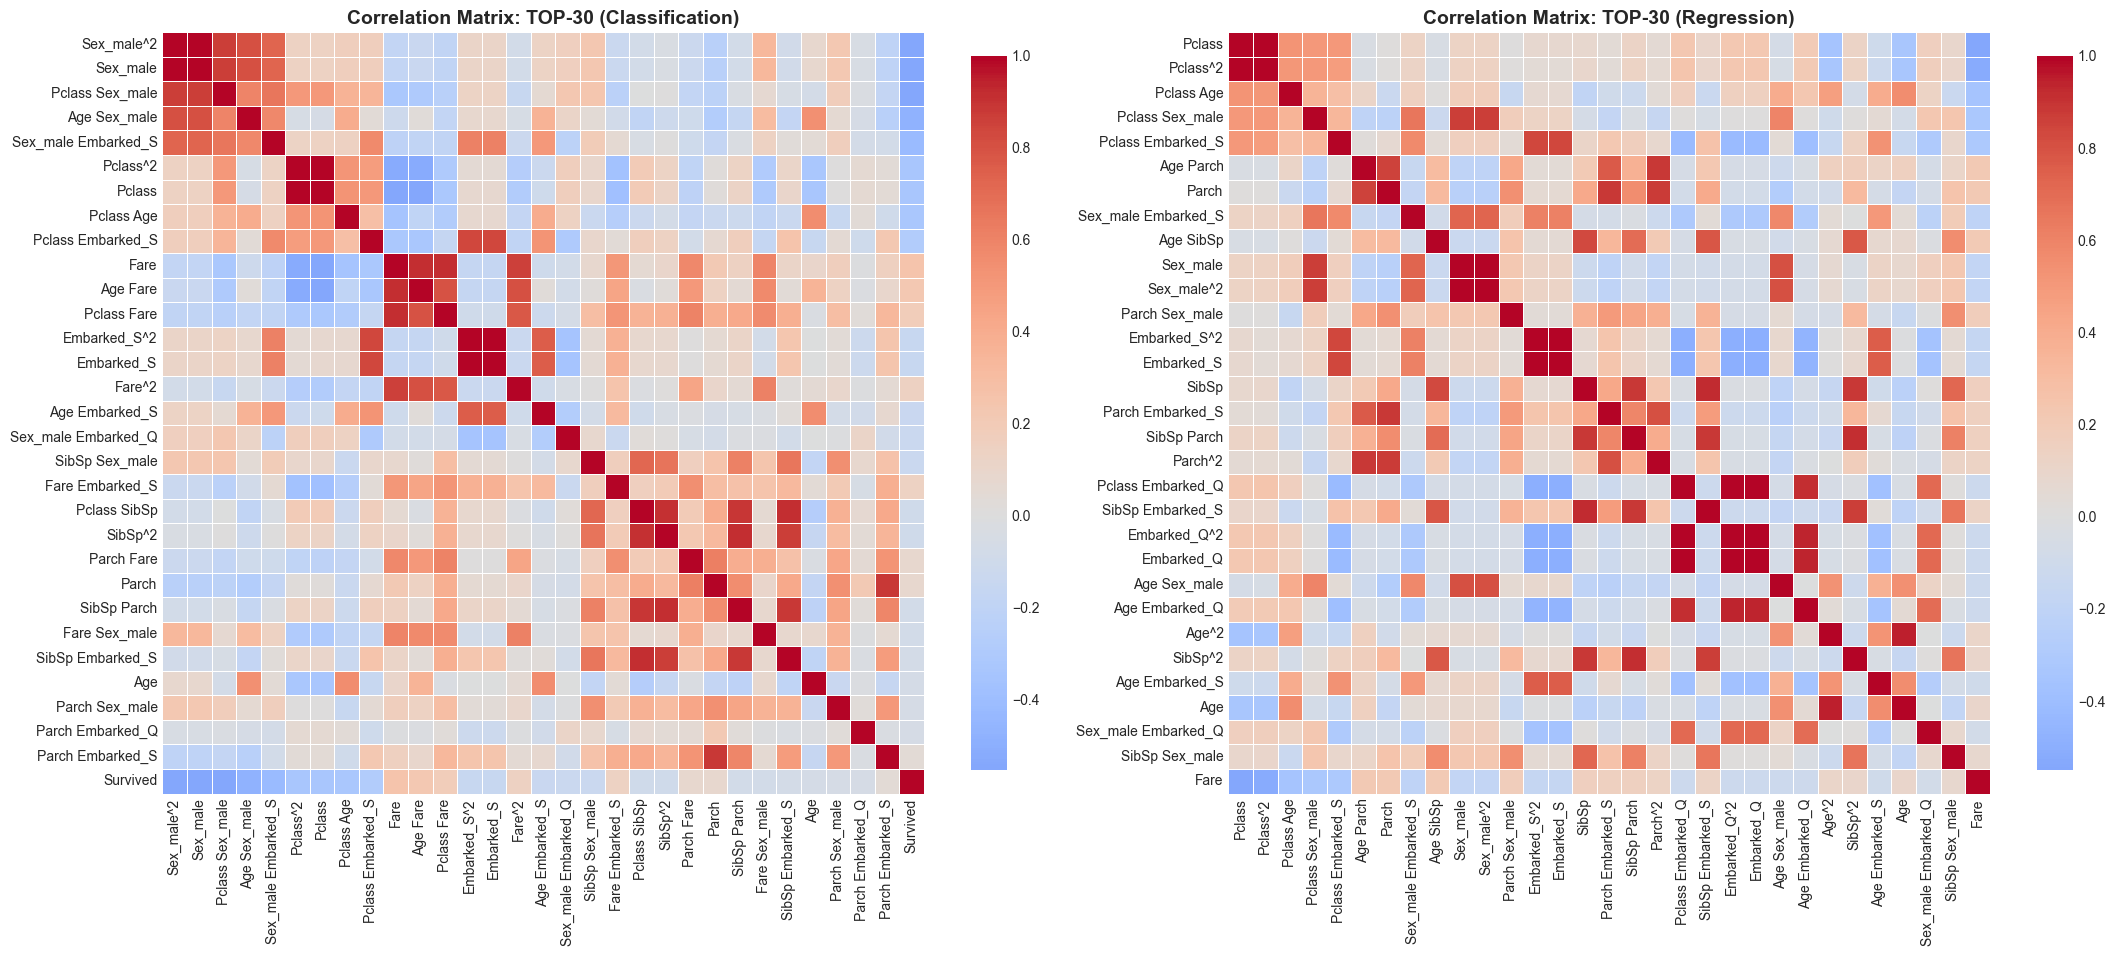

In [11]:
X_poly_clf_df = pd.DataFrame(X_classification_poly, columns=poly_feature_names_classification)
X_poly_clf_df['Survived'] = y_classification.values

X_poly_reg_df = pd.DataFrame(X_regression_poly, columns=poly_feature_names_regression)
X_poly_reg_df['Fare'] = y_regression.values

correlations_clf = X_poly_clf_df.corr()['Survived'].drop('Survived').abs().sort_values(ascending=False)
correlations_reg = X_poly_reg_df.corr()['Fare'].drop('Fare').abs().sort_values(ascending=False)

print("Топ-10 признаков по корреляции (классификация):")
for i, (feat, corr) in enumerate(correlations_clf.head(10).items(), 1):
    print(f"  {i:2d}. {feat[:40]:<40} {corr:.4f}")

print("\nТоп-10 признаков по корреляции (регрессия):")
for i, (feat, corr) in enumerate(correlations_reg.head(10).items(), 1):
    print(f"  {i:2d}. {feat[:40]:<40} {corr:.4f}")

top_n_clf = min(30, len(correlations_clf))
top_features_clf = correlations_clf.head(top_n_clf).index.tolist() + ['Survived']

top_n_reg = min(30, len(correlations_reg))
top_features_reg = correlations_reg.head(top_n_reg).index.tolist() + ['Fare']

fig, axes = plt.subplots(1, 2, figsize=(22, 10))

corr_subset_clf = X_poly_clf_df[top_features_clf].corr()
sns.heatmap(corr_subset_clf, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=axes[0])
axes[0].set_title(f'Correlation Matrix: TOP-{top_n_clf} (Classification)',
                 fontsize=14, fontweight='bold')

corr_subset_reg = X_poly_reg_df[top_features_reg].corr()
sns.heatmap(corr_subset_reg, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=axes[1])
axes[1].set_title(f'Correlation Matrix: TOP-{top_n_reg} (Regression)',
                 fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

del X_poly_clf_df
del X_poly_reg_df


## Пункт 2: Создание baseline и оценка качества

### Этап 3: Подбор оптимального Scaler через Optuna

**Кандидаты**: StandardScaler, MinMaxScaler, RobustScaler, PowerTransformer, QuantileTransformer

## 🎯 Выбор метрик оптимизации

**Классификация - Accuracy:**
- ✅ Сбалансированная метрика (precision × recall)
- ✅ Важна при дисбалансе классов

**Регрессия - Huber Loss:**
- ✅ Робастна к выбросам в Fare
- ✅ MSE для малых ошибок + MAE для больших

In [12]:
def get_scaler(scaler_name):
    """Возвращает scaler по названию"""
    scalers = {
        'standard': StandardScaler(),
        'minmax': MinMaxScaler(),
        'robust': RobustScaler(),
        'power': PowerTransformer(method='yeo-johnson', standardize=True),
        'quantile': QuantileTransformer(output_distribution='normal', random_state=42)
    }
    return scalers.get(scaler_name, StandardScaler())


## Оптимизация Scaler для задачи классификации

Запускаем Optuna study с 25 испытаниями:
- **Целевая метрика**: Accuracy (сбалансированная метрика для классификации)
- **Валидация**: 5-fold cross-validation
- **Базовая модель**: KNN с k=5

Optuna автоматически выбирает лучший scaler на основе качества модели.

In [13]:
def objective_scaler_classification(trial):
    scaler_name = trial.suggest_categorical('scaler',
                                             ['standard', 'minmax', 'robust', 'power', 'quantile'])
    scaler = get_scaler(scaler_name)
    X_scaled = scaler.fit_transform(X_classification_poly)

    knn = KNeighborsClassifier(n_neighbors=5)
    cv_scores = cross_val_score(knn, X_scaled, y_classification, cv=5, scoring='accuracy', n_jobs=-1)

    return cv_scores.mean()

optuna.logging.set_verbosity(optuna.logging.WARNING)
study_scaler_clf = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_scaler_clf.optimize(objective_scaler_classification, n_trials=25, show_progress_bar=True)

best_scaler_clf = study_scaler_clf.best_params['scaler']

with open('step3_scaler_params_clf.json', 'w') as f:
    json.dump({
        'scaler': best_scaler_clf,
        'accuracy': study_scaler_clf.best_value,
        'all_trials': study_scaler_clf.trials_dataframe()['value'].tolist()
    }, f, indent=2)


Best trial: 8. Best value: 0.81934: 100%|██████████| 25/25 [00:05<00:00,  4.43it/s]


## Оптимизация Scaler для задачи регрессии

Аналогичный процесс для задачи регрессии:
- **Целевая метрика**: RMSE (среднеквадратичная ошибка)
- **Валидация**: 5-fold cross-validation
- **Базовая модель**: KNN Regressor с k=5

Результаты сохраняются в JSON для воспроизводимости.

In [14]:
def objective_scaler_regression(trial):
    scaler_name = trial.suggest_categorical('scaler',
                                             ['standard', 'minmax', 'robust', 'power', 'quantile'])
    scaler = get_scaler(scaler_name)
    X_scaled = scaler.fit_transform(X_regression_poly)

    knn = KNeighborsRegressor(n_neighbors=5)
    cv_scores = cross_val_score(knn, X_scaled, y_regression, cv=5,
                                 scoring=huber_scorer, n_jobs=-1)

    return -cv_scores.mean()

study_scaler_reg = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
study_scaler_reg.optimize(objective_scaler_regression, n_trials=25, show_progress_bar=True)

best_scaler_reg = study_scaler_reg.best_params['scaler']

with open('step3_scaler_params_reg.json', 'w') as f:
    json.dump({
        'scaler': best_scaler_reg,
        'huber_loss': study_scaler_reg.best_value,
        'all_trials': study_scaler_reg.trials_dataframe()['value'].tolist()
    }, f, indent=2)


Best trial: 0. Best value: 17.9702: 100%|██████████| 25/25 [00:00<00:00, 56.68it/s]


## Этап 4: Применение выбранных Scaler'ов

Применяем оптимальные scaler'ы к полиномиальным признакам:
- Для классификации: используем scaler, найденный в предыдущем шаге
- Для регрессии: используем свой оптимальный scaler

**Важно**: Scaler'ы сохраняются в pickle-файлы для последующего применения к тестовым данным.

In [15]:
scaler_clf = get_scaler(best_scaler_clf)
X_classification_scaled = scaler_clf.fit_transform(X_classification_poly)

with open('step4_scaler_clf.pkl', 'wb') as f:
    pickle.dump(scaler_clf, f)

scaler_reg = get_scaler(best_scaler_reg)
X_regression_scaled = scaler_reg.fit_transform(X_regression_poly)

with open('step4_scaler_reg.pkl', 'wb') as f:
    pickle.dump(scaler_reg, f)


## Визуализация корреляций после масштабирования

Повторно анализируем корреляции **и для классификации, и для регрессии** после масштабирования признаков. Для каждой задачи строим heatmap по топ-30 признакам, наиболее связанным с целевой переменной.

**Наблюдение**: Масштабирование не меняет корреляции (линейное преобразование), но выводит все признаки в единый масштаб, что критично для KNN и дальнейшего отбора.

Топ-10 признаков по корреляции после масштабирования (классификация):
   1. Pclass Sex_male                          0.5529
   2. Age Sex_male                             0.5457
   3. Sex_male^2                               0.5434
   4. Sex_male                                 0.5434
   5. Sex_male Embarked_S                      0.4259
   6. Fare Sex_male                            0.4123
   7. Pclass                                   0.3397
   8. Pclass^2                                 0.3396
   9. Pclass Age                               0.3340
  10. Fare^2                                   0.3286

Топ-10 признаков по корреляции после масштабирования (регрессия):
   1. Pclass                                   0.5495
   2. Pclass^2                                 0.5197
   3. Pclass Age                               0.3532
   4. Pclass Sex_male                          0.3222
   5. Pclass Embarked_S                        0.3184
   6. Age Parch                                0.2165

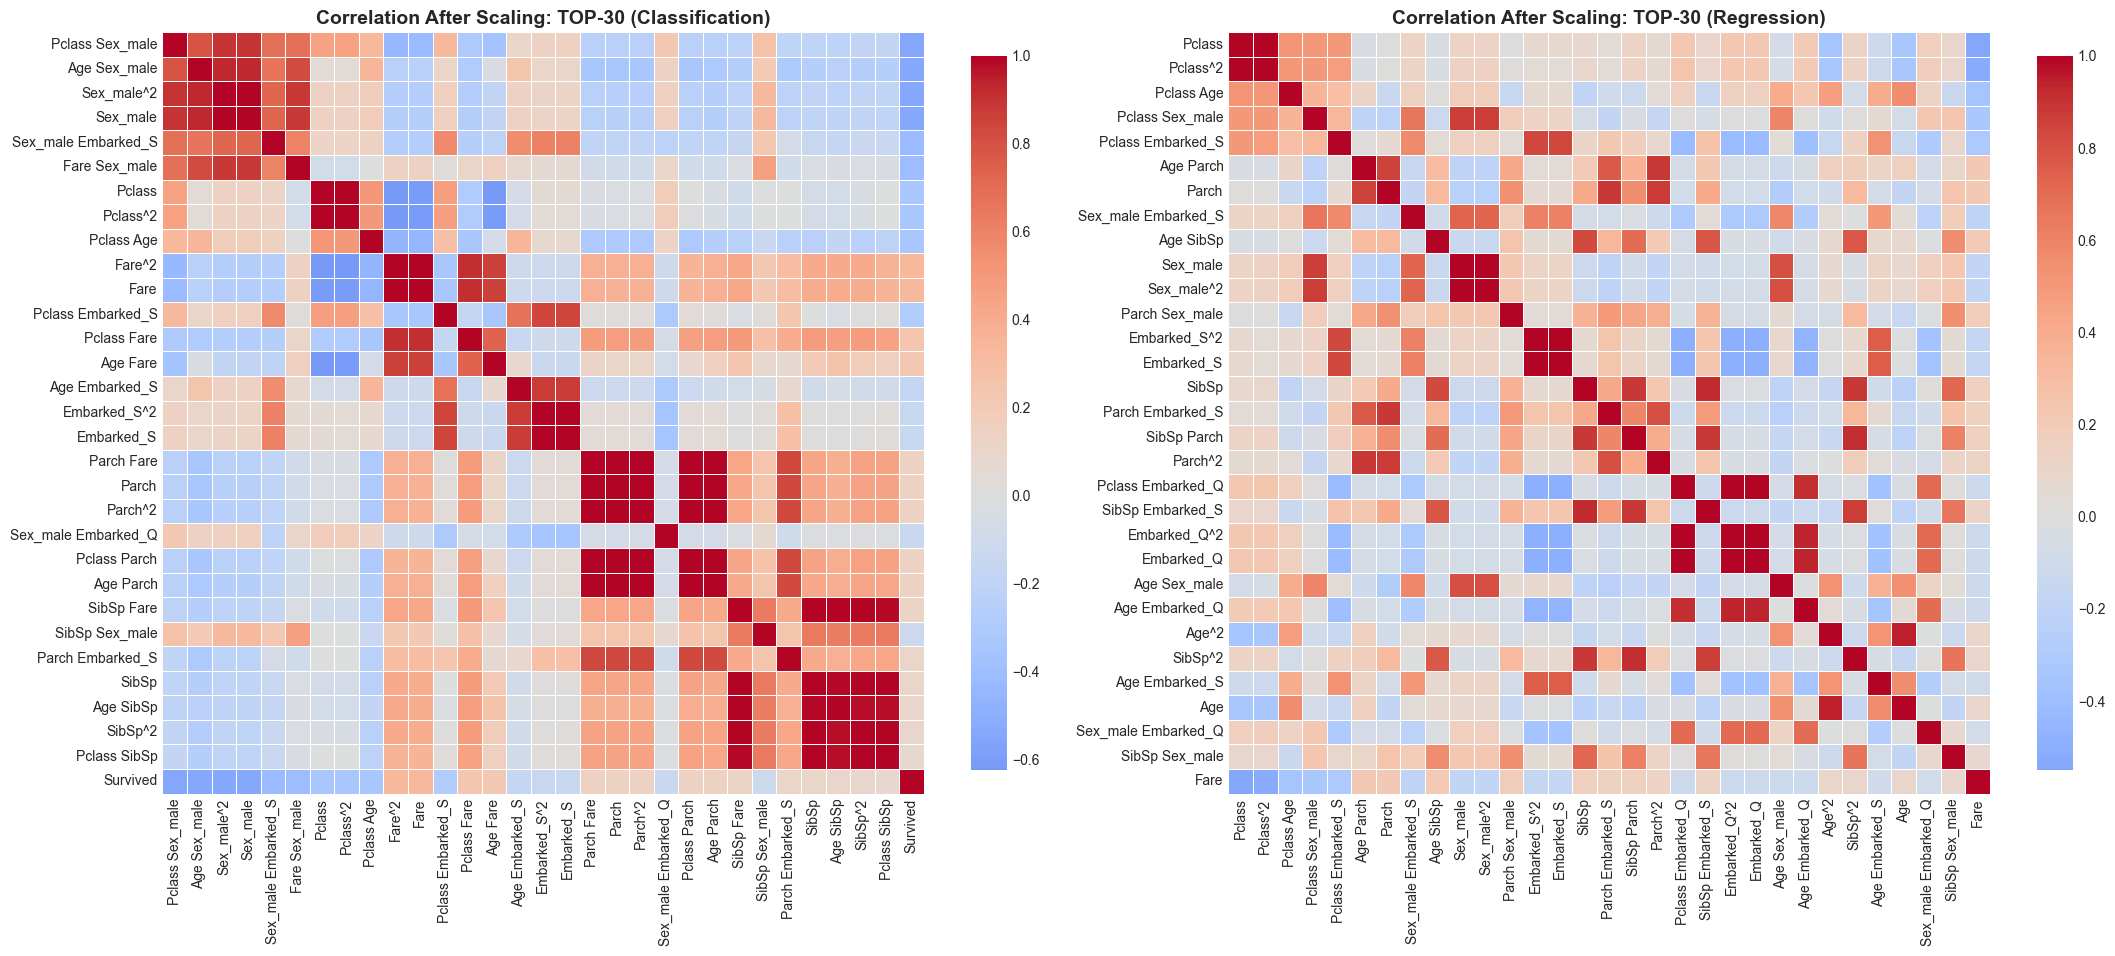

In [16]:
X_scaled_clf_df = pd.DataFrame(X_classification_scaled, columns=poly_feature_names_classification)
X_scaled_clf_df['Survived'] = y_classification.values

X_scaled_reg_df = pd.DataFrame(X_regression_scaled, columns=poly_feature_names_regression)
X_scaled_reg_df['Fare'] = y_regression.values

correlations_scaled_clf = X_scaled_clf_df.corr()['Survived'].drop('Survived').abs().sort_values(ascending=False)
correlations_scaled_reg = X_scaled_reg_df.corr()['Fare'].drop('Fare').abs().sort_values(ascending=False)

print("Топ-10 признаков по корреляции после масштабирования (классификация):")
for i, (feat, corr) in enumerate(correlations_scaled_clf.head(10).items(), 1):
    print(f"  {i:2d}. {feat[:40]:<40} {corr:.4f}")

print("\nТоп-10 признаков по корреляции после масштабирования (регрессия):")
for i, (feat, corr) in enumerate(correlations_scaled_reg.head(10).items(), 1):
    print(f"  {i:2d}. {feat[:40]:<40} {corr:.4f}")

top_n_clf = min(30, len(correlations_scaled_clf))
top_features_scaled_clf = correlations_scaled_clf.head(top_n_clf).index.tolist() + ['Survived']

top_n_reg = min(30, len(correlations_scaled_reg))
top_features_scaled_reg = correlations_scaled_reg.head(top_n_reg).index.tolist() + ['Fare']

fig, axes = plt.subplots(1, 2, figsize=(22, 10))

corr_subset_scaled_clf = X_scaled_clf_df[top_features_scaled_clf].corr()
sns.heatmap(corr_subset_scaled_clf, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=axes[0])
axes[0].set_title(f'Correlation After Scaling: TOP-{top_n_clf} (Classification)',
                 fontsize=14, fontweight='bold')

corr_subset_scaled_reg = X_scaled_reg_df[top_features_scaled_reg].corr()
sns.heatmap(corr_subset_scaled_reg, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=axes[1])
axes[1].set_title(f'Correlation After Scaling: TOP-{top_n_reg} (Regression)',
                 fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

del X_scaled_clf_df
del X_scaled_reg_df


## Пункты 2a-2b: Обучение и оценка Baseline модели

Обучаем базовую KNN-модель с параметрами по умолчанию (k=5):

**Классификация** - оцениваем:
- Accuracy (общая точность)
- Precision (точность положительных предсказаний)
- Recall (полнота обнаружения положительных примеров)

**Регрессия** - оцениваем:
- RMSE (среднеквадратичная ошибка)
- MAE (средняя абсолютная ошибка)
- R² (доля объяснённой дисперсии)

Все метрики вычисляются через 5-fold cross-validation для надёжной оценки.

**Baseline результаты** сохраняются для последующего сравнения с улучшенными моделями.

In [17]:
knn_clf_baseline = KNeighborsClassifier(n_neighbors=5)

cv_f1_base = cross_val_score(knn_clf_baseline, X_classification_scaled, y_classification,
                                    cv=5, scoring='accuracy')
cv_f1_base = cross_val_score(knn_clf_baseline, X_classification_scaled, y_classification,
                              cv=5, scoring='accuracy')
cv_precision_base = cross_val_score(knn_clf_baseline, X_classification_scaled, y_classification,
                                     cv=5, scoring='precision')
cv_recall_base = cross_val_score(knn_clf_baseline, X_classification_scaled, y_classification,
                                  cv=5, scoring='recall')

print("Baseline (5-fold CV):")
print(f"  Accuracy:  {cv_f1_base.mean():.4f} ± {cv_f1_base.std():.4f}")
print(f"  Accuracy:  {cv_f1_base.mean():.4f} ± {cv_f1_base.std():.4f}")
print(f"  Precision: {cv_precision_base.mean():.4f} ± {cv_precision_base.std():.4f}")
print(f"  Recall:    {cv_recall_base.mean():.4f} ± {cv_recall_base.std():.4f}")

baseline_clf = {
    'accuracy': cv_f1_base.mean(),
    'f1': cv_f1_base.mean(),
    'precision': cv_precision_base.mean(),
    'recall': cv_recall_base.mean()
}

knn_reg_baseline = KNeighborsRegressor(n_neighbors=5)

cv_huber_base = -cross_val_score(knn_reg_baseline, X_regression_scaled, y_regression,
                                 cv=5, scoring=huber_scorer)
cv_mae_base = -cross_val_score(knn_reg_baseline, X_regression_scaled, y_regression,
                                cv=5, scoring='neg_mean_absolute_error')
cv_r2_base = cross_val_score(knn_reg_baseline, X_regression_scaled, y_regression,
                              cv=5, scoring='r2')

print(f"  RMSE: {cv_huber_base.mean():.4f} ± {cv_huber_base.std():.4f}")
print(f"  MAE:  {cv_mae_base.mean():.4f} ± {cv_mae_base.std():.4f}")
print(f"  R²:   {cv_r2_base.mean():.4f} ± {cv_r2_base.std():.4f}")

baseline_reg = {
    'huber_loss': cv_huber_base.mean(),
    'mae': cv_mae_base.mean(),
    'r2': cv_r2_base.mean()
}

with open('step4_baseline_results.json', 'w') as f:
    json.dump({
        'classification': baseline_clf,
        'regression': baseline_reg
    }, f, indent=2)


Baseline (5-fold CV):
  Accuracy:  0.8193 ± 0.0291
  Accuracy:  0.8193 ± 0.0291
  Precision: 0.7998 ± 0.0487
  Recall:    0.7076 ± 0.0308
  RMSE: 18.0481 ± 3.2510
  MAE:  13.9328 ± 2.4141
  R²:   0.4696 ± 0.0902


## Пункт 3: Улучшение baseline

### Пункт 3a: Формулирование гипотез для улучшения

**Гипотеза 1 (Boruta)**: Полная оптимизация параметров алгоритма Boruta отберёт оптимальное подмножество признаков из полиномиального пространства, удалив шумовые признаки.

**Гипотеза 2 (RFECV)**: Рекурсивное удаление признаков с permutation importance улучшит качество, т.к. правильно работает с KNN (в отличие от feature_importances_).

**Гипотеза 3 (Гиперпараметры KNN)**: Полная оптимизация гиперпараметров (k, метрика расстояния, веса) даст значительный прирост качества.

**Гипотеза 4 (Адаптивное CV)**: Оптимизация количества фолдов в кросс-валидации повысит стабильность оценки качества.

## Пункт 3b: Проверка гипотез - Boruta для классификации

### Этап 5: Boruta + Optuna с расширенной оптимизацией

**Boruta** - алгоритм отбора признаков на основе Random Forest:
- Создаёт "теневые" признаки (перемешанные копии)
- Сравнивает importance реальных признаков с теневыми
- Отбирает только статистически значимые признаки

**Оптимизация через Optuna (50 trials)**:
- **Параметры Boruta**: max_iter (30-200), perc (85-100), alpha (0.001-0.2)
- **Параметры Random Forest**: n_estimators, max_depth, min_samples_split/leaf, max_features, class_weight

Расширенные диапазоны параметров позволяют найти оптимальную конфигурацию для конкретного датасета.

In [18]:
def objective_boruta_classification(trial):
    max_iter = trial.suggest_int('max_iter', 30, 200)
    perc = trial.suggest_int('perc', 85, 100)
    alpha = trial.suggest_float('alpha', 0.001, 0.2)

    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    rf_max_depth = trial.suggest_int('rf_max_depth', 2, 7)
    rf_min_samples_split = trial.suggest_int('rf_min_samples_split', 2, 15)
    rf_min_samples_leaf = trial.suggest_int('rf_min_samples_leaf', 1, 7)
    rf_max_features = trial.suggest_categorical('rf_max_features', ['sqrt', 'log2', None])

    class_weight = trial.suggest_categorical('class_weight', ['balanced', 'balanced_subsample', None])

    rf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=rf_max_depth,
        min_samples_split=rf_min_samples_split,
        min_samples_leaf=rf_min_samples_leaf,
        max_features=rf_max_features,
        class_weight=class_weight,
        n_jobs=-1,
        random_state=42
    )

    boruta = BorutaPy(
        estimator=rf,
        n_estimators='auto',
        max_iter=max_iter,
        perc=perc,
        alpha=alpha,
        verbose=0,
        random_state=42
    )

    try:
        boruta.fit(X_classification_scaled, y_classification.values)
        selected_mask = boruta.support_ | boruta.support_weak_

        if selected_mask.sum() == 0:
            return 0.0

        X_selected = X_classification_scaled[:, selected_mask]

        knn = KNeighborsClassifier(n_neighbors=5)
        cv_scores = cross_val_score(knn, X_selected, y_classification, cv=3, scoring='accuracy', n_jobs=-1)

        return cv_scores.mean()
    except Exception as e:
        print(f"Error: {e}")
        return 0.0

study_boruta_clf = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_boruta_clf.optimize(objective_boruta_classification, n_trials=50, show_progress_bar=True)

best_boruta_params_clf = study_boruta_clf.best_params
for k, v in best_boruta_params_clf.items():
    print(f"  {k}: {v}")


Best trial: 3. Best value: 0.824916: 100%|██████████| 50/50 [07:46<00:00,  9.33s/it]

  max_iter: 105
  perc: 86
  alpha: 0.09954020511214277
  n_estimators: 58
  rf_max_depth: 7
  rf_min_samples_split: 5
  rf_min_samples_leaf: 5
  rf_max_features: None
  class_weight: balanced_subsample


## Применение Boruta с оптимальными параметрами (Классификация)

Запускаем Boruta с найденными оптимальными параметрами:
- Отбираем значимые признаки
- Включаем weak_features (признаки с пограничной значимостью)
- Сохраняем результаты для воспроизводимости

**Результат**: Сокращение размерности с удалением шумовых признаков, что должно улучшить обобщающую способность модели.

In [19]:
rf_boruta_clf = RandomForestClassifier(
    n_estimators=best_boruta_params_clf['n_estimators'],
    max_depth=best_boruta_params_clf['rf_max_depth'],
    min_samples_split=best_boruta_params_clf['rf_min_samples_split'],
    min_samples_leaf=best_boruta_params_clf['rf_min_samples_leaf'],
    max_features=best_boruta_params_clf['rf_max_features'],
    class_weight=best_boruta_params_clf['class_weight'],
    n_jobs=-1,
    random_state=42
)

boruta_selector_clf = BorutaPy(
    estimator=rf_boruta_clf,
    n_estimators='auto',
    max_iter=best_boruta_params_clf['max_iter'],
    perc=best_boruta_params_clf['perc'],
    alpha=best_boruta_params_clf['alpha'],
    verbose=0,
    random_state=42
)

boruta_selector_clf.fit(X_classification_scaled, y_classification.values)

selected_mask_clf = boruta_selector_clf.support_ | boruta_selector_clf.support_weak_
selected_features_clf_names = poly_feature_names_classification[selected_mask_clf]
X_classification_boruta = X_classification_scaled[:, selected_mask_clf]

print(f"Исходно: {X_classification_scaled.shape[1]} признаков")
print(f"Отобрано: {len(selected_features_clf_names)} признаков")
print(f"Удалено: {X_classification_scaled.shape[1] - len(selected_features_clf_names)} мусорных признаков")

with open('step5_boruta_features_clf.json', 'w') as f:
    json.dump({
        'selected_features': selected_features_clf_names.tolist(),
        'n_features': len(selected_features_clf_names),
        'boruta_params': best_boruta_params_clf,
        'accuracy': study_boruta_clf.best_value
    }, f, indent=2)


Исходно: 44 признаков
Отобрано: 6 признаков
Удалено: 38 мусорных признаков


## Пункт 3b: Boruta для регрессии

Аналогичный процесс для задачи регрессии:
- Используем RandomForestRegressor вместо Classifier
- Целевая метрика: RMSE
- Оптимизация тех же параметров

Регрессия и классификация требуют независимой оптимизации, т.к. важность признаков может различаться.

In [20]:
def objective_boruta_regression(trial):
    max_iter = trial.suggest_int('max_iter', 30, 200)
    perc = trial.suggest_int('perc', 85, 100)
    alpha = trial.suggest_float('alpha', 0.001, 0.2)

    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    rf_max_depth = trial.suggest_int('rf_max_depth', 2, 7)
    rf_min_samples_split = trial.suggest_int('rf_min_samples_split', 2, 15)
    rf_min_samples_leaf = trial.suggest_int('rf_min_samples_leaf', 1, 7)
    rf_max_features = trial.suggest_categorical('rf_max_features', ['sqrt', 'log2', None])

    rf = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=rf_max_depth,
        min_samples_split=rf_min_samples_split,
        min_samples_leaf=rf_min_samples_leaf,
        max_features=rf_max_features,
        n_jobs=-1,
        random_state=42
    )

    boruta = BorutaPy(
        estimator=rf,
        n_estimators='auto',
        max_iter=max_iter,
        perc=perc,
        alpha=alpha,
        verbose=0,
        random_state=42
    )

    try:
        boruta.fit(X_regression_scaled, y_regression.values)
        selected_mask = boruta.support_ | boruta.support_weak_

        if selected_mask.sum() == 0:
            return 1000.0

        X_selected = X_regression_scaled[:, selected_mask]

        knn = KNeighborsRegressor(n_neighbors=5)
        cv_scores = cross_val_score(knn, X_selected, y_regression, cv=3,
                                     scoring=huber_scorer, n_jobs=-1)

        return -cv_scores.mean()
    except Exception as e:
        print(f"Error: {e}")
        return 1000.0

study_boruta_reg = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
study_boruta_reg.optimize(objective_boruta_regression, n_trials=50, show_progress_bar=True)

best_boruta_params_reg = study_boruta_reg.best_params
for k, v in best_boruta_params_reg.items():
    print(f"  {k}: {v}")


Best trial: 47. Best value: 16.9408: 100%|██████████| 50/50 [06:05<00:00,  7.31s/it]

  max_iter: 139
  perc: 89
  alpha: 0.1260372364455773
  n_estimators: 52
  rf_max_depth: 6
  rf_min_samples_split: 2
  rf_min_samples_leaf: 7
  rf_max_features: None


## Применение Boruta с оптимальными параметрами (Регрессия)

Применяем Boruta с оптимальными параметрами к задаче регрессии.

Сохраняем отобранные признаки и параметры для последующего использования.

In [21]:
rf_boruta_reg = RandomForestRegressor(
    n_estimators=best_boruta_params_reg['n_estimators'],
    max_depth=best_boruta_params_reg['rf_max_depth'],
    min_samples_split=best_boruta_params_reg['rf_min_samples_split'],
    min_samples_leaf=best_boruta_params_reg['rf_min_samples_leaf'],
    max_features=best_boruta_params_reg['rf_max_features'],
    n_jobs=-1,
    random_state=42
)

boruta_selector_reg = BorutaPy(
    estimator=rf_boruta_reg,
    n_estimators='auto',
    max_iter=best_boruta_params_reg['max_iter'],
    perc=best_boruta_params_reg['perc'],
    alpha=best_boruta_params_reg['alpha'],
    verbose=0,
    random_state=42
)

boruta_selector_reg.fit(X_regression_scaled, y_regression.values)

selected_mask_reg = boruta_selector_reg.support_ | boruta_selector_reg.support_weak_
selected_features_reg_names = poly_feature_names_regression[selected_mask_reg]
X_regression_boruta = X_regression_scaled[:, selected_mask_reg]

print(f"Исходно: {X_regression_scaled.shape[1]} признаков")
print(f"Отобрано: {len(selected_features_reg_names)} признаков")
print(f"Удалено: {X_regression_scaled.shape[1] - len(selected_features_reg_names)} мусорных признаков")

with open('step5_boruta_features_reg.json', 'w') as f:
    json.dump({
        'selected_features': selected_features_reg_names.tolist(),
        'n_features': len(selected_features_reg_names),
        'boruta_params': best_boruta_params_reg,
        'huber_loss': study_boruta_reg.best_value
    }, f, indent=2)


Исходно: 35 признаков
Отобрано: 8 признаков
Удалено: 27 мусорных признаков


## Визуализация результатов Boruta

Визуализируем ranking признаков после Boruta:
- **Зелёные столбцы**: отобранные признаки (ranking = 1)
- **Красные столбцы**: отвергнутые признаки (ranking > 1)
- **Вертикальная линия**: порог отбора

Это помогает интерпретировать, какие признаки алгоритм считает наиболее важными.

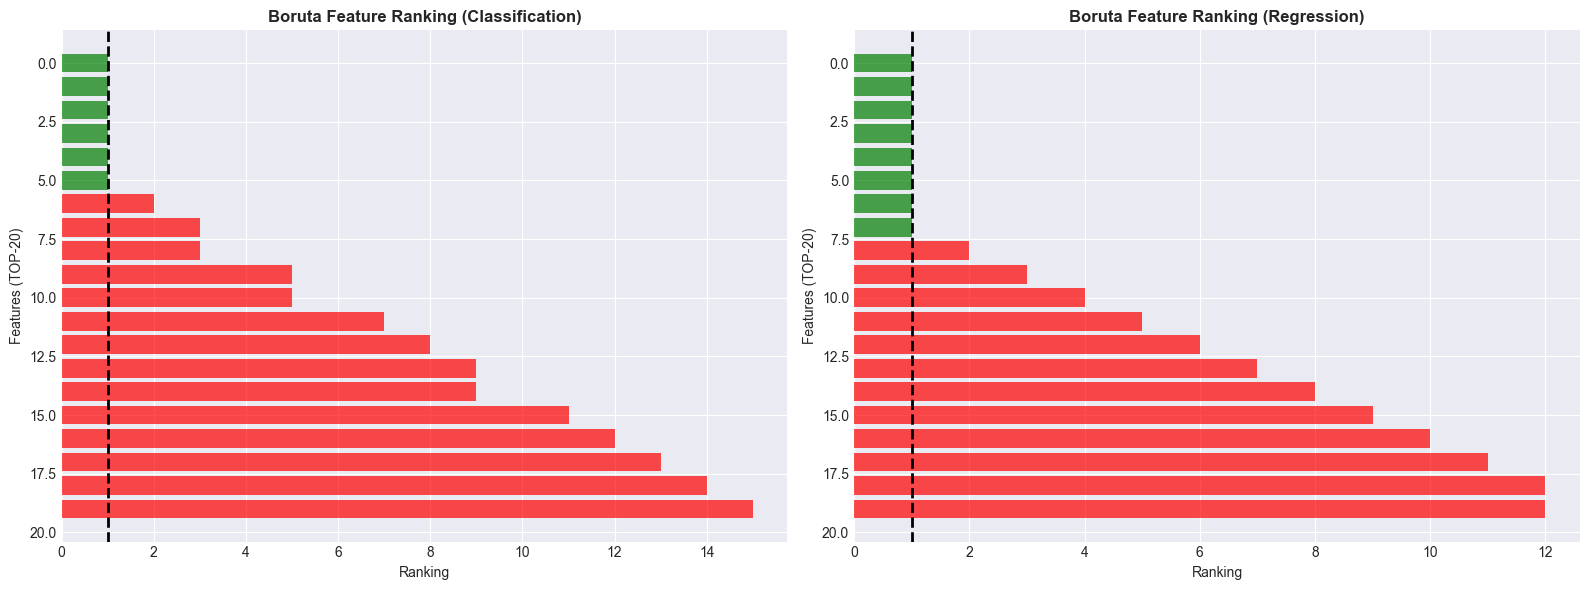

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

feature_ranks_clf = pd.DataFrame({
    'Feature': poly_feature_names_classification,
    'Ranking': boruta_selector_clf.ranking_,
    'Selected': selected_mask_clf
})
feature_ranks_clf = feature_ranks_clf.sort_values('Ranking')
colors_clf = ['green' if x else 'red' for x in feature_ranks_clf['Selected']]

top_show = min(20, len(feature_ranks_clf))
axes[0].barh(range(top_show), feature_ranks_clf['Ranking'].values[:top_show],
             color=colors_clf[:top_show], alpha=0.7)
axes[0].set_xlabel('Ranking')
axes[0].set_ylabel('Features (TOP-20)')
axes[0].set_title('Boruta Feature Ranking (Classification)', fontweight='bold')
axes[0].axvline(x=1, color='black', linestyle='--', linewidth=2)
axes[0].invert_yaxis()

feature_ranks_reg = pd.DataFrame({
    'Feature': poly_feature_names_regression,
    'Ranking': boruta_selector_reg.ranking_,
    'Selected': selected_mask_reg
})
feature_ranks_reg = feature_ranks_reg.sort_values('Ranking')
colors_reg = ['green' if x else 'red' for x in feature_ranks_reg['Selected']]

axes[1].barh(range(top_show), feature_ranks_reg['Ranking'].values[:top_show],
             color=colors_reg[:top_show], alpha=0.7)
axes[1].set_xlabel('Ranking')
axes[1].set_ylabel('Features (TOP-20)')
axes[1].set_title('Boruta Feature Ranking (Regression)', fontweight='bold')
axes[1].axvline(x=1, color='black', linestyle='--', linewidth=2)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


## Анализ корреляций после Boruta

Строим корреляционные матрицы **для классификации и регрессии** по признакам, отобранным Boruta.

**Цель**: Убедиться, что отобранные признаки имеют высокую связь с целевой переменной и умеренную мультиколлинеарность между собой в обеих задачах.

Топ-10 отобранных признаков (классификация):
   1. Age Sex_male                             0.5457
   2. Pclass^2                                 0.3396
   3. Pclass Age                               0.3340
   4. Pclass Embarked_S                        0.2811
   5. Pclass Fare                              0.2334
   6. Age Fare                                 0.2235

Топ-10 отобранных признаков (регрессия):
   1. Pclass                                   0.5495
   2. Pclass^2                                 0.5197
   3. Age Parch                                0.2165
   4. Sex_male Embarked_S                      0.2091
   5. Age SibSp                                0.2012
   6. SibSp Parch                              0.1485
   7. Age Sex_male                             0.1148
   8. Age                                      0.0967


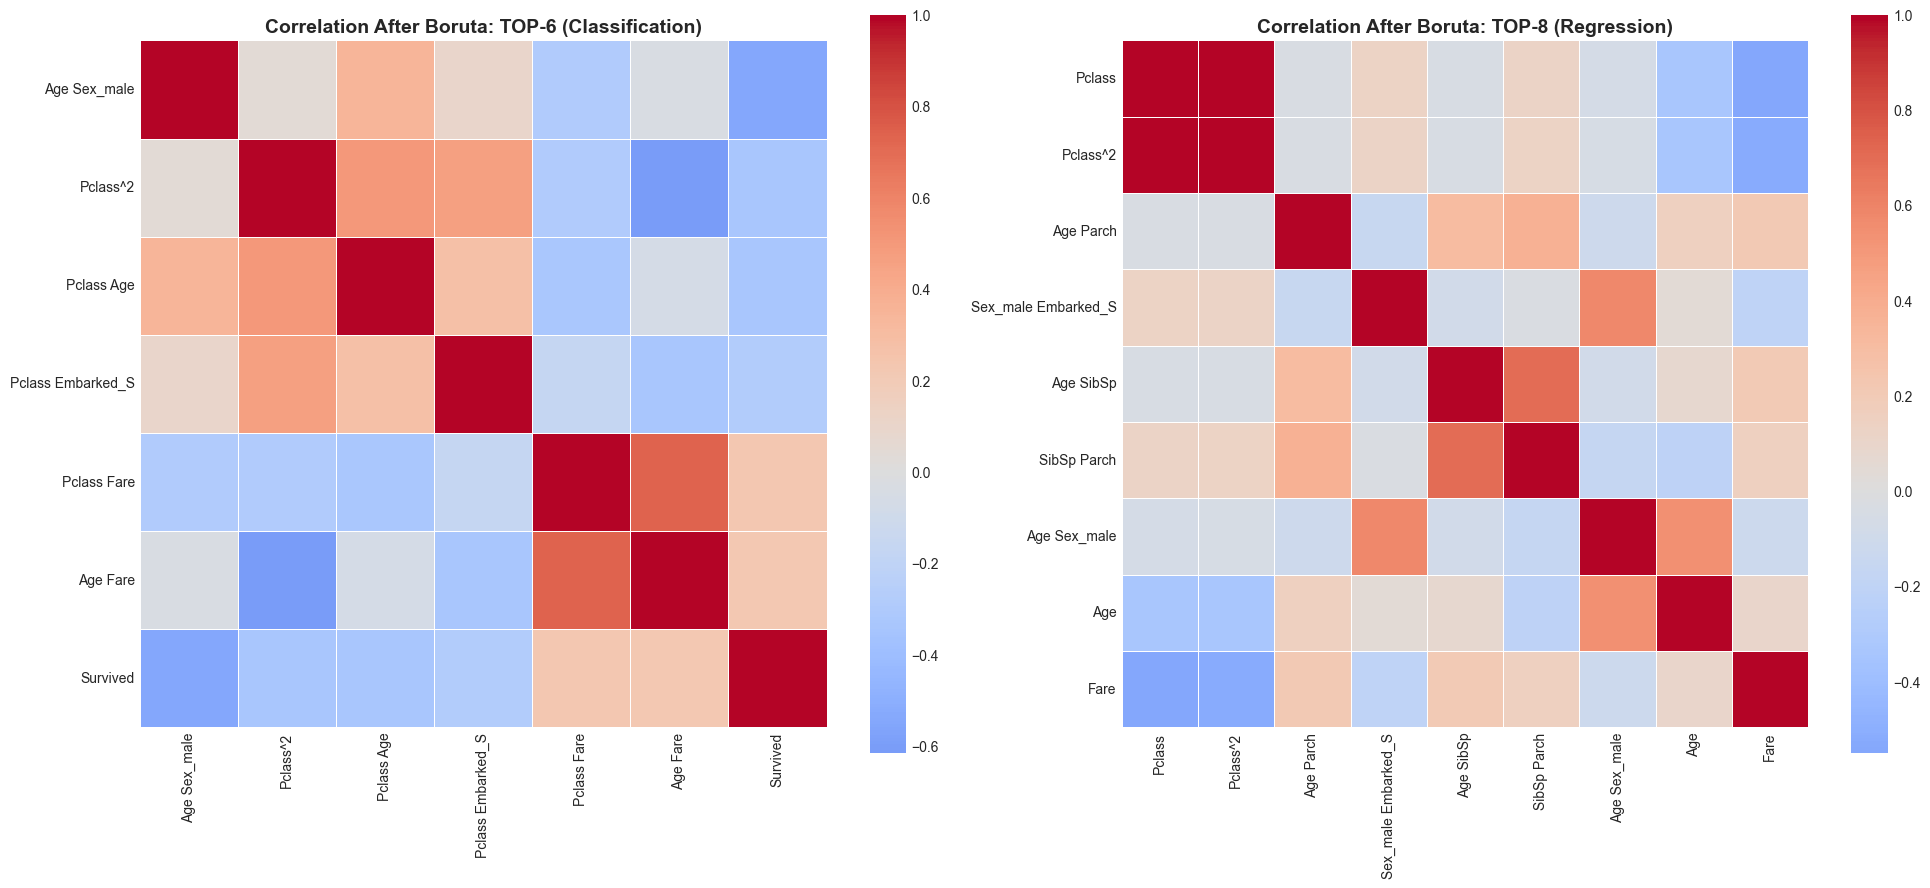

In [23]:
X_boruta_clf_df = pd.DataFrame(X_classification_boruta, columns=selected_features_clf_names)
X_boruta_clf_df['Survived'] = y_classification.values

X_boruta_reg_df = pd.DataFrame(X_regression_boruta, columns=selected_features_reg_names)
X_boruta_reg_df['Fare'] = y_regression.values

correlations_boruta_clf = X_boruta_clf_df.corr()['Survived'].drop('Survived').abs().sort_values(ascending=False)
correlations_boruta_reg = X_boruta_reg_df.corr()['Fare'].drop('Fare').abs().sort_values(ascending=False)

print("Топ-10 отобранных признаков (классификация):")
for i, (feat, corr) in enumerate(correlations_boruta_clf.head(10).items(), 1):
    print(f"  {i:2d}. {feat[:40]:<40} {corr:.4f}")

print("\nТоп-10 отобранных признаков (регрессия):")
for i, (feat, corr) in enumerate(correlations_boruta_reg.head(10).items(), 1):
    print(f"  {i:2d}. {feat[:40]:<40} {corr:.4f}")

top_n_boruta_clf = min(25, len(selected_features_clf_names))
top_features_boruta_clf = correlations_boruta_clf.head(top_n_boruta_clf).index.tolist() + ['Survived']

top_n_boruta_reg = min(25, len(selected_features_reg_names))
top_features_boruta_reg = correlations_boruta_reg.head(top_n_boruta_reg).index.tolist() + ['Fare']

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

corr_subset_boruta_clf = X_boruta_clf_df[top_features_boruta_clf].corr()
sns.heatmap(corr_subset_boruta_clf, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=axes[0])
axes[0].set_title(f'Correlation After Boruta: TOP-{top_n_boruta_clf} (Classification)',
                 fontsize=14, fontweight='bold')

corr_subset_boruta_reg = X_boruta_reg_df[top_features_boruta_reg].corr()
sns.heatmap(corr_subset_boruta_reg, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=axes[1])
axes[1].set_title(f'Correlation After Boruta: TOP-{top_n_boruta_reg} (Regression)',
                 fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

del X_boruta_clf_df
del X_boruta_reg_df


## Этап 6: Полная оптимизация KNN + RFECV

### Класс PermutationImportanceGetter

**Проблема**: KNN не имеет встроенного `feature_importances_`, поэтому стандартный RFECV не работает.

**Решение**: Создаём класс-обёртку для вычисления важности признаков через permutation importance:
- RFECV вызывает `__call__` с обученной моделью
- Мы вычисляем важность через перестановку признаков
- Используем n_repeats=5 для стабильности оценки

Это позволяет корректно применять RFECV к KNN.

In [24]:
class PermutationImportanceGetter:
    """
    Класс для вычисления важности признаков через permutation importance.
    RFECV вызывает __call__ с fitted estimator.
    """
    def __init__(self, X, y, n_repeats=5):
        self.X = X
        self.y = y
        self.n_repeats = n_repeats

    def __call__(self, estimator):
        """RFECV вызывает это с уже обученным estimator"""
        try:
            if hasattr(estimator, 'n_features_in_'):
                n_features = estimator.n_features_in_
                result = permutation_importance(
                    estimator,
                    self.X[:, :n_features] if self.X.shape[1] >= n_features else self.X,
                    self.y,
                    n_repeats=self.n_repeats,
                    random_state=42,
                    n_jobs=1
                )
                return result.importances_mean
        except:
            pass

        result = permutation_importance(
            estimator,
            self.X,
            self.y,
            n_repeats=self.n_repeats,
            random_state=42,
            n_jobs=1
        )
        return result.importances_mean


def objective_full_classification(trial):
    n_neighbors = trial.suggest_int('n_neighbors', 2, 50)
    weights = trial.suggest_categorical('weights', ['uniform', 'distance'])
    metric = trial.suggest_categorical('metric', ['euclidean', 'manhattan', 'minkowski', 'chebyshev'])
    p = trial.suggest_int('p', 1, 5) if metric == 'minkowski' else 2
    algorithm = trial.suggest_categorical('algorithm', ['auto', 'ball_tree', 'kd_tree', 'brute'])

    min_features = trial.suggest_int('min_features_to_select', 3,
                                      min(30, X_classification_boruta.shape[1]))
    rfecv_step = trial.suggest_int('rfecv_step', 1, 5)

    cv_folds = trial.suggest_int('cv_folds', 3, 10)

    knn_params = {
        'n_neighbors': n_neighbors,
        'weights': weights,
        'algorithm': algorithm,
        'metric': metric
    }
    if metric == 'minkowski':
        knn_params['p'] = p

    knn = KNeighborsClassifier(**knn_params)

    importance_getter = PermutationImportanceGetter(
        X_classification_boruta,
        y_classification,
        n_repeats=3
    )

    rfecv = RFECV(
        estimator=knn,
        step=rfecv_step,
        cv=4,
        scoring='accuracy',
        min_features_to_select=min_features,
        importance_getter=importance_getter,
        n_jobs=1
    )

    try:
        rfecv.fit(X_classification_boruta, y_classification)
        X_selected = X_classification_boruta[:, rfecv.support_]

        if X_selected.shape[1] == 0:
            return 0.0

        cv_scores = cross_val_score(knn, X_selected, y_classification,
                                     cv=cv_folds, scoring='accuracy', n_jobs=-1)

        return cv_scores.mean()
    except Exception as e:
        print(f"Error in trial: {e}")
        return 0.0

study_full_clf = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_full_clf.optimize(objective_full_classification, n_trials=150, show_progress_bar=True)

best_params_clf = study_full_clf.best_params
for k, v in best_params_clf.items():
    print(f"  {k}: {v}")

with open('step6_optimal_params_clf.json', 'w') as f:
    json.dump({
        'best_params': best_params_clf,
        'best_accuracy': study_full_clf.best_value
    }, f, indent=2)


Best trial: 74. Best value: 0.82722: 100%|██████████| 150/150 [01:10<00:00,  2.11it/s]

  n_neighbors: 27
  weights: distance
  metric: manhattan
  algorithm: auto
  min_features_to_select: 3
  rfecv_step: 5
  cv_folds: 7


## Пункты 3c-3e: Полная оптимизация для классификации

Запускаем комплексную оптимизацию через Optuna (150 trials):

**Оптимизируемые параметры**:
- **KNN**: n_neighbors (2-50), weights (uniform/distance), metric (euclidean/manhattan/minkowski/chebyshev), algorithm, p для minkowski
- **RFECV**: min_features_to_select, step
- **Cross-Validation**: количество фолдов (3-10)

**Процесс**:
1. Optuna выбирает гиперпараметры
2. RFECV отбирает признаки с этими параметрами
3. Модель оценивается через CV
4. Optuna максимизирует Accuracy

Это наиболее вычислительно затратный, но эффективный этап.

In [25]:
knn_params_clf = {
    'n_neighbors': best_params_clf['n_neighbors'],
    'weights': best_params_clf['weights'],
    'algorithm': best_params_clf['algorithm'],
    'metric': best_params_clf['metric']
}
if best_params_clf['metric'] == 'minkowski' and 'p' in best_params_clf:
    knn_params_clf['p'] = best_params_clf['p']

knn_clf_improved = KNeighborsClassifier(**knn_params_clf)

importance_getter_clf = PermutationImportanceGetter(
    X_classification_boruta,
    y_classification,
    n_repeats=10
)

rfecv_clf = RFECV(
    estimator=knn_clf_improved,
    step=best_params_clf['rfecv_step'],
    cv=4,
    scoring='accuracy',
    min_features_to_select=best_params_clf['min_features_to_select'],
    importance_getter=importance_getter_clf,
    n_jobs=1
)

rfecv_clf.fit(X_classification_boruta, y_classification)
X_clf_final = X_classification_boruta[:, rfecv_clf.support_]

final_features_clf = selected_features_clf_names[rfecv_clf.support_]

print(f"После Boruta: {X_classification_boruta.shape[1]} признаков")
print(f"После RFECV: {X_clf_final.shape[1]} признаков")
print(f"Итого удалено: {X_classification_scaled.shape[1] - X_clf_final.shape[1]} признаков")

cv_folds = best_params_clf['cv_folds']
cv_f1_improved = cross_val_score(knn_clf_improved, X_clf_final, y_classification,
                                        cv=cv_folds, scoring='accuracy')
cv_f1_improved = cross_val_score(knn_clf_improved, X_clf_final, y_classification,
                                  cv=cv_folds, scoring='accuracy')
cv_precision_improved = cross_val_score(knn_clf_improved, X_clf_final, y_classification,
                                         cv=cv_folds, scoring='precision')
cv_recall_improved = cross_val_score(knn_clf_improved, X_clf_final, y_classification,
                                      cv=cv_folds, scoring='recall')

print(f"  Accuracy:  {cv_f1_improved.mean():.4f} ± {cv_f1_improved.std():.4f}")
print(f"  Accuracy:  {cv_f1_improved.mean():.4f} ± {cv_f1_improved.std():.4f}")
print(f"  Precision: {cv_precision_improved.mean():.4f} ± {cv_precision_improved.std():.4f}")
print(f"  Recall:    {cv_recall_improved.mean():.4f} ± {cv_recall_improved.std():.4f}")

improved_clf = {
    'accuracy': cv_f1_improved.mean(),
    'f1': cv_f1_improved.mean(),
    'precision': cv_precision_improved.mean(),
    'recall': cv_recall_improved.mean()
}

print(f"\n📈 СРАВНЕНИЕ С BASELINE:")
print(f"  Accuracy: {baseline_clf['f1']:.4f} → {improved_clf['f1']:.4f} "
      f"({(improved_clf['f1']-baseline_clf['f1'])*100:+.2f}%)")
print(f"  Accuracy: {baseline_clf['f1']:.4f} → {improved_clf['f1']:.4f} "
      f"({(improved_clf['f1']-baseline_clf['f1'])*100:+.2f}%)")


После Boruta: 6 признаков
После RFECV: 6 признаков
Итого удалено: 38 признаков
  Accuracy:  0.8272 ± 0.0225
  Accuracy:  0.8272 ± 0.0225
  Precision: 0.8071 ± 0.0367
  Recall:    0.7254 ± 0.0557

📈 СРАВНЕНИЕ С BASELINE:
  Accuracy: 0.8193 → 0.8272 (+0.79%)
  Accuracy: 0.8193 → 0.8272 (+0.79%)


## Пункты 3d-3f: Обучение улучшенной модели (Классификация)

Обучаем финальную модель с оптимальными параметрами:
1. Создаём KNN с найденными гиперпараметрами
2. Применяем RFECV для финального отбора признаков
3. Оцениваем качество через адаптивное CV

**Сравнение с baseline**:
- Показываем абсолютное и относительное улучшение метрик
- Анализируем, насколько эффективна была оптимизация

**Выводы (3g)**:
- Оцениваем успешность каждой гипотезы
- Формулируем ключевые инсайты

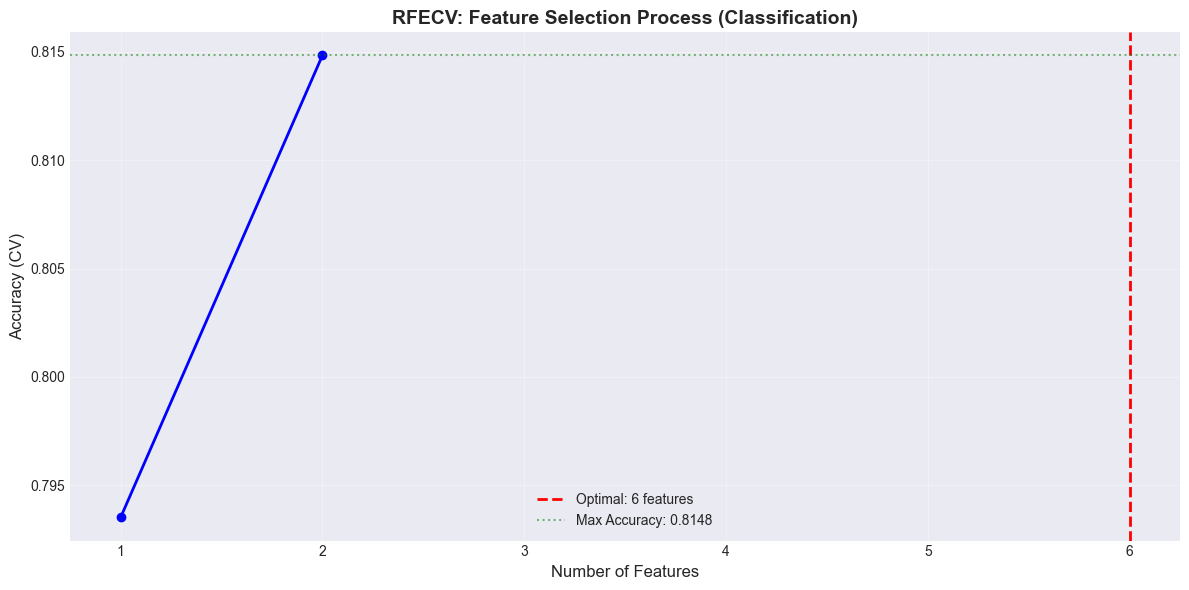

In [26]:
plt.figure(figsize=(12, 6))
n_features_range = range(1, len(rfecv_clf.cv_results_['mean_test_score']) + 1)
plt.plot(n_features_range, rfecv_clf.cv_results_['mean_test_score'],
         marker='o', linewidth=2, markersize=6, color='blue')
plt.xlabel('Number of Features', fontsize=12)
plt.ylabel('Accuracy (CV)', fontsize=12)
plt.title('RFECV: Feature Selection Process (Classification)', fontsize=14, fontweight='bold')
plt.axvline(x=rfecv_clf.n_features_, color='red', linestyle='--', linewidth=2,
            label=f'Optimal: {rfecv_clf.n_features_} features')
plt.axhline(y=rfecv_clf.cv_results_['mean_test_score'].max(),
            color='green', linestyle=':', alpha=0.5,
            label=f'Max Accuracy: {rfecv_clf.cv_results_["mean_test_score"].max():.4f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Визуализация процесса RFECV (Классификация)

График показывает зависимость Accuracy от количества отобранных признаков:
- **Красная линия**: оптимальное количество признаков
- **Зелёная линия**: максимально достигнутый Accuracy

Это помогает понять, как качество зависит от числа признаков и найден ли оптимум.

Финальные признаки (всего 6):
   1. Age Sex_male                                  0.5457
   2. Pclass^2                                      0.3396
   3. Pclass Age                                    0.3340
   4. Pclass Embarked_S                             0.2811
   5. Pclass Fare                                   0.2334
   6. Age Fare                                      0.2235


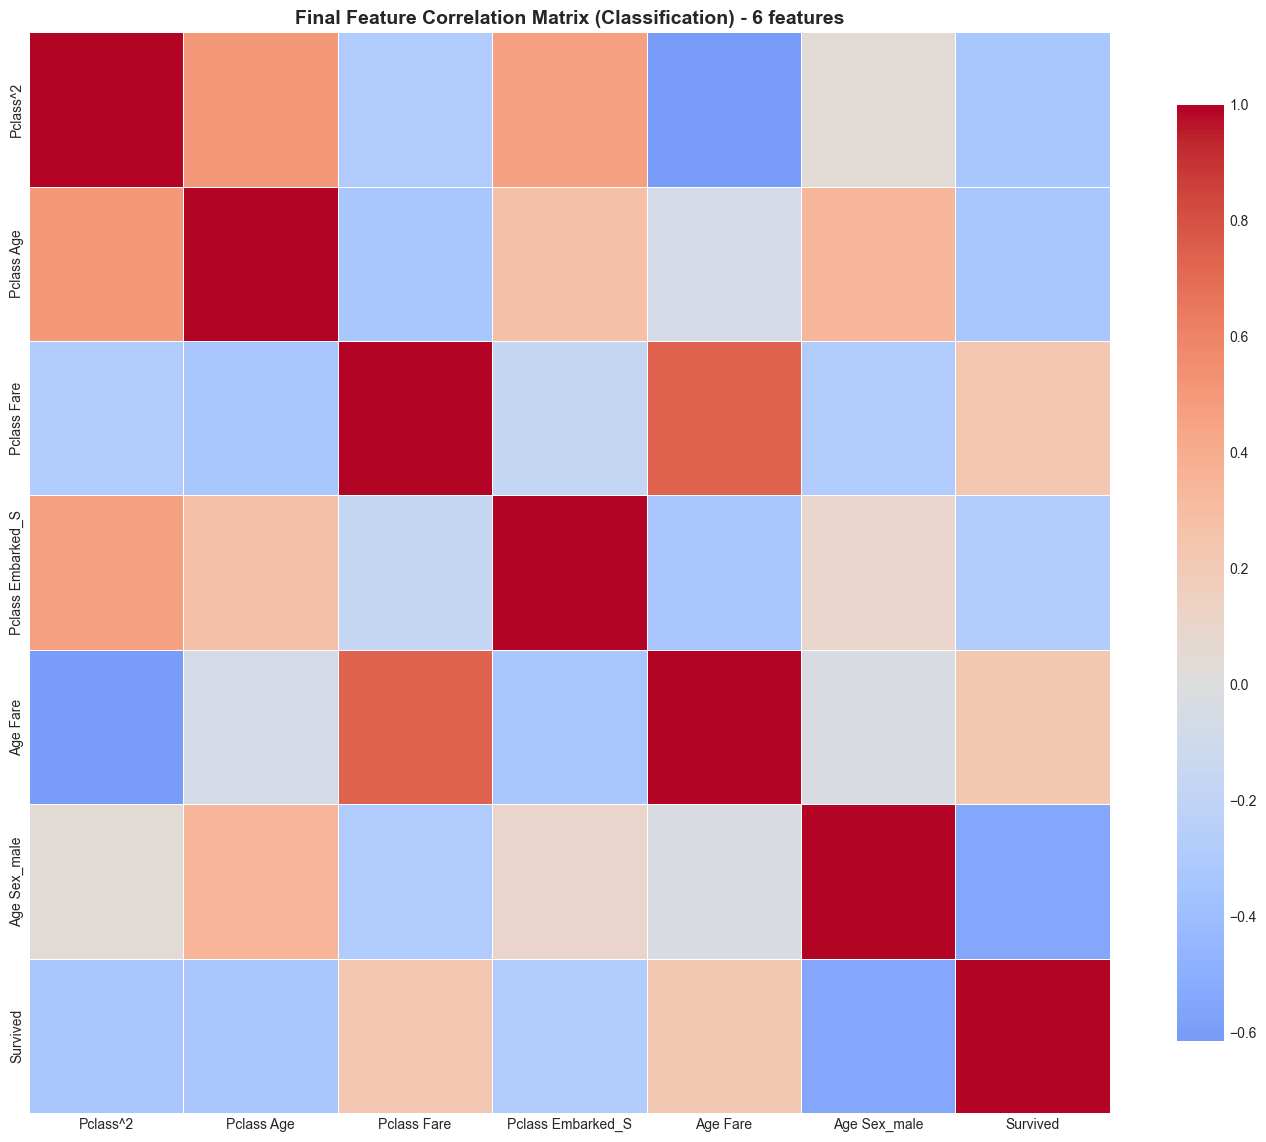

In [27]:
X_final_clf_df = pd.DataFrame(X_clf_final, columns=final_features_clf)
X_final_clf_df['Survived'] = y_classification.values

correlations_final = X_final_clf_df.corr()['Survived'].drop('Survived').abs().sort_values(ascending=False)

print(f"Финальные признаки (всего {len(final_features_clf)}):")
for i, (feat, corr) in enumerate(correlations_final.items(), 1):
    print(f"  {i:2d}. {feat[:45]:<45} {corr:.4f}")

if len(final_features_clf) <= 25:
    plt.figure(figsize=(14, 12))
    sns.heatmap(X_final_clf_df.corr(), annot=False, cmap='coolwarm', center=0,
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
    plt.title(f'Final Feature Correlation Matrix (Classification) - {len(final_features_clf)} features',
              fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    top_k = min(25, len(correlations_final))
    plt.figure(figsize=(10, 8))
    corr_top = correlations_final.head(top_k)
    plt.barh(range(top_k), corr_top.values, color='#3498db', alpha=0.8)
    plt.yticks(range(top_k), [f[:40] for f in corr_top.index])
    plt.gca().invert_yaxis()
    plt.xlabel('Absolute correlation with Survived')
    plt.title(f'TOP-{top_k} Final Features by Correlation (Classification)')
    plt.tight_layout()
    plt.show()

del X_final_clf_df


## Анализ финальных признаков (Классификация)

Визуализируем финальный набор признаков после всех этапов отбора: heatmap (если признаков немного) или bar-chart с топовыми корреляциями (если признаков много). Отдельный анализ для регрессии — ниже.

**Результат**: Компактный набор наиболее информативных и слабо скоррелированных признаков, оптимальный для KNN-классификатора.

In [28]:
def objective_full_regression(trial):
    n_neighbors = trial.suggest_int('n_neighbors', 2, 50)
    weights = trial.suggest_categorical('weights', ['uniform', 'distance'])
    metric = trial.suggest_categorical('metric', ['euclidean', 'manhattan', 'minkowski', 'chebyshev'])
    p = trial.suggest_int('p', 1, 5) if metric == 'minkowski' else 2
    algorithm = trial.suggest_categorical('algorithm', ['auto', 'ball_tree', 'kd_tree', 'brute'])

    min_features = trial.suggest_int('min_features_to_select', 3,
                                      min(30, X_regression_boruta.shape[1]))
    rfecv_step = trial.suggest_int('rfecv_step', 1, 5)

    cv_folds = trial.suggest_int('cv_folds', 3, 10)

    knn_params = {
        'n_neighbors': n_neighbors,
        'weights': weights,
        'algorithm': algorithm,
        'metric': metric
    }
    if metric == 'minkowski':
        knn_params['p'] = p

    knn = KNeighborsRegressor(**knn_params)

    importance_getter = PermutationImportanceGetter(
        X_regression_boruta,
        y_regression,
        n_repeats=3
    )

    rfecv = RFECV(
        estimator=knn,
        step=rfecv_step,
        cv=4,
        scoring='neg_mean_squared_error',
        min_features_to_select=min_features,
        importance_getter=importance_getter,
        n_jobs=1
    )

    try:
        rfecv.fit(X_regression_boruta, y_regression)
        X_selected = X_regression_boruta[:, rfecv.support_]

        if X_selected.shape[1] == 0:
            return 1000.0

        cv_scores = cross_val_score(knn, X_selected, y_regression,
                                     cv=cv_folds, scoring=huber_scorer,
                                     n_jobs=-1)

        return -cv_scores.mean()
    except Exception as e:
        print(f"Error in trial: {e}")
        return 1000.0

study_full_reg = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
study_full_reg.optimize(objective_full_regression, n_trials=150, show_progress_bar=True)

best_params_reg = study_full_reg.best_params
for k, v in best_params_reg.items():
    print(f"  {k}: {v}")

with open('step6_optimal_params_reg.json', 'w') as f:
    json.dump({
        'best_params': best_params_reg,
        'best_rmse': study_full_reg.best_value
    }, f, indent=2)


Best trial: 97. Best value: 16.8078: 100%|██████████| 150/150 [00:35<00:00,  4.18it/s]

  n_neighbors: 5
  weights: uniform
  metric: minkowski
  p: 4
  algorithm: auto
  min_features_to_select: 8
  rfecv_step: 3
  cv_folds: 10


## Пункты 3c-3e: Полная оптимизация для регрессии

Аналогичный процесс для задачи регрессии:
- Те же оптимизируемые параметры
- Целевая метрика: RMSE (минимизация)
- 150 trials для тщательного поиска

Регрессия требует отдельной оптимизации, т.к. оптимальные параметры могут отличаться от классификации.

## Пункты 3d-3f: Обучение улучшенной модели (Регрессия)

Обучение финальной модели для регрессии с оптимальными параметрами:
1. KNN Regressor с оптимизированными гиперпараметрами
2. RFECV для отбора признаков
3. Финальная оценка качества + визуализация финального набора признаков (heatmap/bar)

**Сравнение с baseline**:
- Улучшение RMSE (снижение ошибки)
- Улучшение R² (объяснённая дисперсия)

**Выводы**: Оценка эффективности примененных техник.

После Boruta: 8 признаков
После RFECV: 8 признаков
Итого удалено: 27 признаков
  RMSE: 16.8078 ± 4.0096
  MAE:  13.0110 ± 2.9783
  R²:   0.4542 ± 0.1074

📈 СРАВНЕНИЕ С BASELINE:
  RMSE: 18.0481 → 16.8078 (1.2403 ↓)
  R²:   0.4696 → 0.4542 (-1.54%)

Финальные признаки регрессии (всего 8):
   1. Pclass                                        0.5495
   2. Pclass^2                                      0.5197
   3. Age Parch                                     0.2165
   4. Sex_male Embarked_S                           0.2091
   5. Age SibSp                                     0.2012
   6. SibSp Parch                                   0.1485
   7. Age Sex_male                                  0.1148
   8. Age                                           0.0967


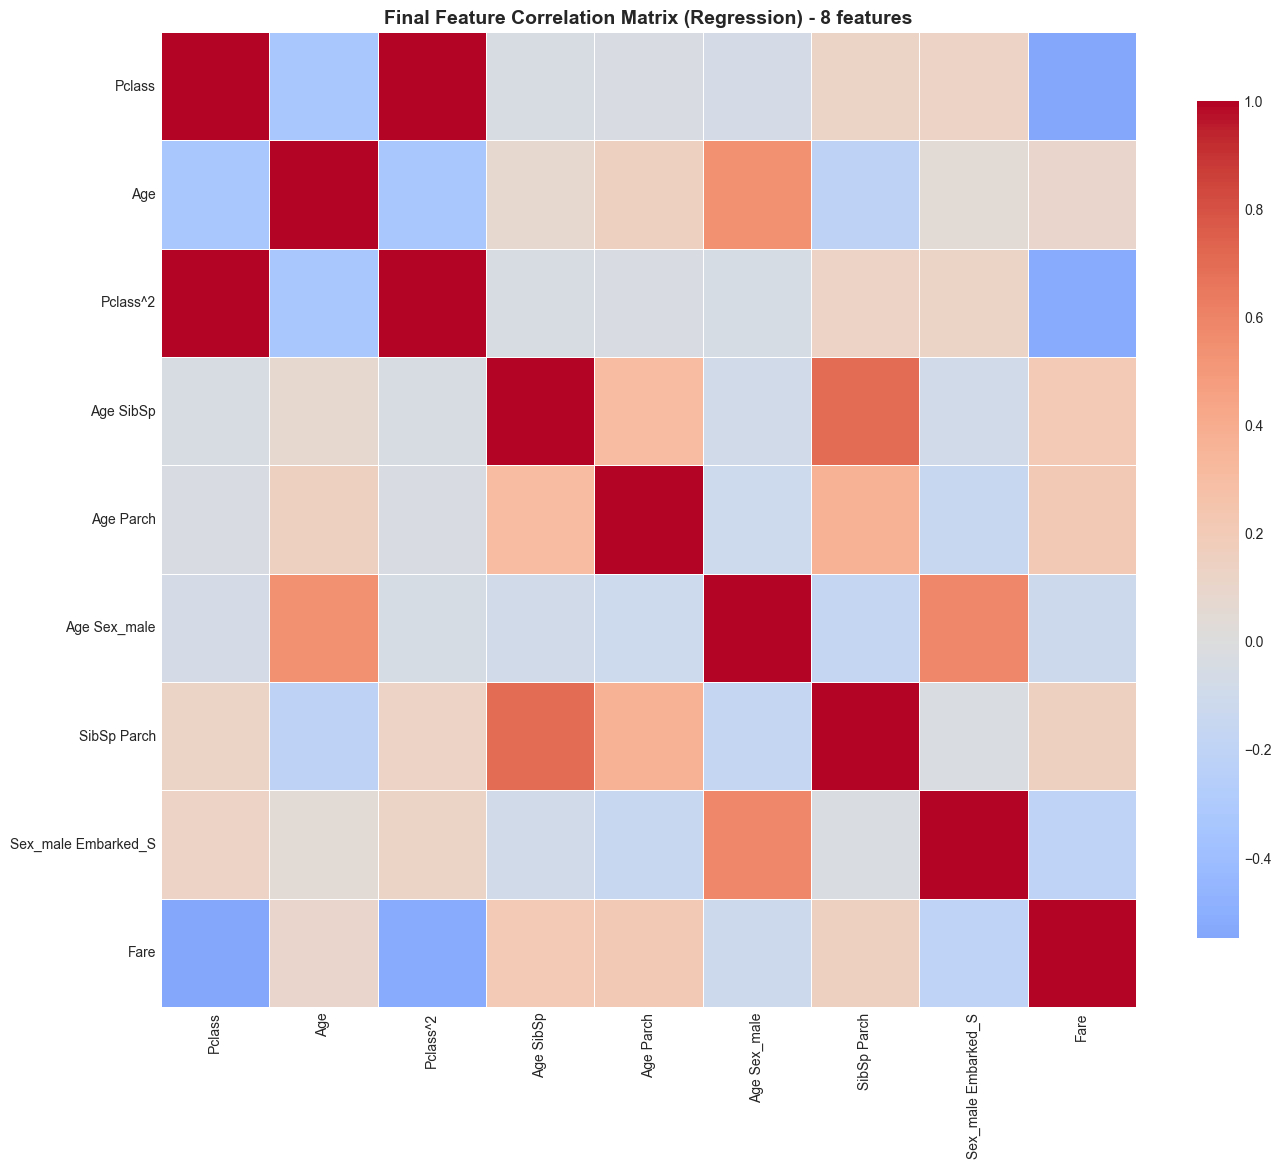

In [49]:
knn_params_reg = {
    'n_neighbors': best_params_reg['n_neighbors'],
    'weights': best_params_reg['weights'],
    'algorithm': best_params_reg['algorithm'],
    'metric': best_params_reg['metric']
}
if best_params_reg['metric'] == 'minkowski' and 'p' in best_params_reg:
    knn_params_reg['p'] = best_params_reg['p']

knn_reg_improved = KNeighborsRegressor(**knn_params_reg)

importance_getter_reg = PermutationImportanceGetter(
    X_regression_boruta,
    y_regression,
    n_repeats=10
)

rfecv_reg = RFECV(
    estimator=knn_reg_improved,
    step=best_params_reg['rfecv_step'],
    cv=4,
    scoring='neg_mean_squared_error',
    min_features_to_select=best_params_reg['min_features_to_select'],
    importance_getter=importance_getter_reg,
    n_jobs=1
)

rfecv_reg.fit(X_regression_boruta, y_regression)
X_reg_final = X_regression_boruta[:, rfecv_reg.support_]

final_features_reg = selected_features_reg_names[rfecv_reg.support_]

print(f"После Boruta: {X_regression_boruta.shape[1]} признаков")
print(f"После RFECV: {X_reg_final.shape[1]} признаков")
print(f"Итого удалено: {X_regression_scaled.shape[1] - X_reg_final.shape[1]} признаков")

cv_folds = best_params_reg['cv_folds']
cv_huber_improved = -cross_val_score(knn_reg_improved, X_reg_final, y_regression,
                                     cv=cv_folds, scoring=huber_scorer)
cv_mae_improved = -cross_val_score(knn_reg_improved, X_reg_final, y_regression,
                                    cv=cv_folds, scoring='neg_mean_absolute_error')
cv_r2_improved = cross_val_score(knn_reg_improved, X_reg_final, y_regression,
                                  cv=cv_folds, scoring='r2')

print(f"  RMSE: {cv_huber_improved.mean():.4f} ± {cv_huber_improved.std():.4f}")
print(f"  MAE:  {cv_mae_improved.mean():.4f} ± {cv_mae_improved.std():.4f}")
print(f"  R²:   {cv_r2_improved.mean():.4f} ± {cv_r2_improved.std():.4f}")

improved_reg = {
    'huber_loss': cv_huber_improved.mean(),
    'mae': cv_mae_improved.mean(),
    'r2': cv_r2_improved.mean()
}

print(f"\n📈 СРАВНЕНИЕ С BASELINE:")
print(f"  RMSE: {baseline_reg['huber_loss']:.4f} → {improved_reg['huber_loss']:.4f} "
      f"({baseline_reg['huber_loss']-improved_reg['huber_loss']:.4f} ↓)")
print(f"  R²:   {baseline_reg['r2']:.4f} → {improved_reg['r2']:.4f} "
      f"({(improved_reg['r2']-baseline_reg['r2'])*100:+.2f}%)")

# Визуализация финальных признаков регрессии
reg_final_df = pd.DataFrame(X_reg_final, columns=final_features_reg)
reg_final_df['Fare'] = y_regression.values
correlations_final_reg = reg_final_df.corr()['Fare'].drop('Fare').abs().sort_values(ascending=False)

print(f"\nФинальные признаки регрессии (всего {len(final_features_reg)}):")
for i, (feat, corr) in enumerate(correlations_final_reg.items(), 1):
    print(f"  {i:2d}. {feat[:45]:<45} {corr:.4f}")

if len(final_features_reg) <= 25:
    plt.figure(figsize=(14, 12))
    sns.heatmap(reg_final_df.corr(), annot=False, cmap='coolwarm', center=0,
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
    plt.title(f'Final Feature Correlation Matrix (Regression) - {len(final_features_reg)} features',
              fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    top_k = min(25, len(correlations_final_reg))
    plt.figure(figsize=(10, 8))
    corr_top = correlations_final_reg.head(top_k)
    plt.barh(range(top_k), corr_top.values, color='#2ecc71', alpha=0.8)
    plt.yticks(range(top_k), [f[:40] for f in corr_top.index])
    plt.gca().invert_yaxis()
    plt.xlabel('Absolute correlation with Fare')
    plt.title(f'TOP-{top_k} Final Features by Correlation (Regression)')
    plt.tight_layout()
    plt.show()

del reg_final_df


## Пункт 4: Имплементация алгоритма машинного обучения

### Пункт 4a: Собственная реализация KNN

В этом разделе реализуем алгоритм KNN с нуля для:
- Понимания внутреннего устройства алгоритма
- Проверки корректности работы sklearn
- Демонстрации владения алгоритмами ML

In [31]:
from sklearn.base import BaseEstimator, ClassifierMixin, RegressorMixin
class KNNClassifierOptimized(BaseEstimator, ClassifierMixin):
    """
    Оптимизированная имплементация KNN для классификации
    - Наследуется от BaseEstimator для совместимости с sklearn API
    - Векторизация через NumPy broadcasting
    - Поддержка всех метрик distance
    - Эффективная работа с большими массивами
    """
    def __init__(self, n_neighbors=5, weights='uniform', metric='euclidean', p=2, algorithm='auto'):
        self.n_neighbors = n_neighbors
        self.weights = weights
        self.metric = metric
        self.p = p
        self.algorithm = algorithm
    
    def fit(self, X, y):
        """Обучение (запоминание данных)"""
        self.X_train_ = np.asarray(X, dtype=np.float64)
        self.y_train_ = np.asarray(y, dtype=np.int64)
        self.classes_ = np.unique(self.y_train_)
        return self
    
    def _calculate_distances(self, X_test):
        """Векторизованное вычисление расстояний"""
        diff = X_test[:, np.newaxis, :] - self.X_train_[np.newaxis, :, :]
        
        if self.metric == 'euclidean':
            distances = np.sqrt(np.sum(diff ** 2, axis=2))
        elif self.metric == 'manhattan':
            distances = np.sum(np.abs(diff), axis=2)
        elif self.metric == 'minkowski':
            distances = np.sum(np.abs(diff) ** self.p, axis=2) ** (1/self.p)
        elif self.metric == 'chebyshev':
            distances = np.max(np.abs(diff), axis=2)
        else:
            distances = np.sqrt(np.sum(diff ** 2, axis=2))
        
        return distances
    
    def predict(self, X):
        """Векторизованное предсказание"""
        X_test = np.asarray(X, dtype=np.float64)
        distances = self._calculate_distances(X_test)
        
        k_actual = min(self.n_neighbors, distances.shape[1])
        k_indices = np.argpartition(distances, k_actual - 1, axis=1)[:, :k_actual]
        k_nearest_labels = self.y_train_[k_indices]
        
        predictions = np.zeros(len(X_test), dtype=np.int64)
        
        if self.weights == 'uniform':
            for i in range(len(X_test)):
                unique, counts = np.unique(k_nearest_labels[i], return_counts=True)
                predictions[i] = unique[np.argmax(counts)]
        else:  # distance
            k_distances = np.take_along_axis(distances, k_indices, axis=1)
            k_distances = np.where(k_distances == 0, 1e-10, k_distances)
            weights_array = 1 / k_distances
            
            for i in range(len(X_test)):
                class_votes = {}
                for label, weight in zip(k_nearest_labels[i], weights_array[i]):
                    class_votes[label] = class_votes.get(label, 0) + weight
                predictions[i] = max(class_votes, key=class_votes.get)
        
        return predictions
    
    def predict_proba(self, X):
        """Предсказание вероятностей классов"""
        X_test = np.asarray(X, dtype=np.float64)
        distances = self._calculate_distances(X_test)
        
        k_actual = min(self.n_neighbors, distances.shape[1])
        k_indices = np.argpartition(distances, k_actual - 1, axis=1)[:, :k_actual]
        k_nearest_labels = self.y_train_[k_indices]
        
        probas = np.zeros((len(X_test), len(self.classes_)))
        
        if self.weights == 'uniform':
            for i in range(len(X_test)):
                for j, cls in enumerate(self.classes_):
                    probas[i, j] = np.sum(k_nearest_labels[i] == cls) / k_actual
        else:  # distance
            k_distances = np.take_along_axis(distances, k_indices, axis=1)
            k_distances = np.where(k_distances == 0, 1e-10, k_distances)
            weights_array = 1 / k_distances
            
            for i in range(len(X_test)):
                for j, cls in enumerate(self.classes_):
                    mask = k_nearest_labels[i] == cls
                    probas[i, j] = np.sum(weights_array[i][mask])
                if np.sum(probas[i]) > 0:
                    probas[i] /= np.sum(probas[i])
        
        return probas
    
    def score(self, X, y):
        """Accuracy"""
        return np.mean(self.predict(X) == y)


class KNNRegressorOptimized(BaseEstimator, RegressorMixin):
    """
    Оптимизированная имплементация KNN для регрессии
    - Наследуется от BaseEstimator для совместимости с sklearn API
    """
    def __init__(self, n_neighbors=5, weights='uniform', metric='euclidean', p=2, algorithm='auto'):
        self.n_neighbors = n_neighbors
        self.weights = weights
        self.metric = metric
        self.p = p
        self.algorithm = algorithm
    
    def fit(self, X, y):
        """Обучение (запоминание данных)"""
        self.X_train_ = np.asarray(X, dtype=np.float64)
        self.y_train_ = np.asarray(y, dtype=np.float64)
        return self
    
    def _calculate_distances(self, X_test):
        """Векторизованное вычисление расстояний"""
        diff = X_test[:, np.newaxis, :] - self.X_train_[np.newaxis, :, :]
        
        if self.metric == 'euclidean':
            distances = np.sqrt(np.sum(diff ** 2, axis=2))
        elif self.metric == 'manhattan':
            distances = np.sum(np.abs(diff), axis=2)
        elif self.metric == 'minkowski':
            distances = np.sum(np.abs(diff) ** self.p, axis=2) ** (1/self.p)
        elif self.metric == 'chebyshev':
            distances = np.max(np.abs(diff), axis=2)
        else:
            distances = np.sqrt(np.sum(diff ** 2, axis=2))
        
        return distances
    
    def predict(self, X):
        """Векторизованное предсказание"""
        X_test = np.asarray(X, dtype=np.float64)
        distances = self._calculate_distances(X_test)
        
        k_actual = min(self.n_neighbors, distances.shape[1])
        k_indices = np.argpartition(distances, k_actual - 1, axis=1)[:, :k_actual]
        k_nearest_values = self.y_train_[k_indices]
        
        if self.weights == 'uniform':
            predictions = np.mean(k_nearest_values, axis=1)
        else:  # distance
            k_distances = np.take_along_axis(distances, k_indices, axis=1)
            k_distances = np.where(k_distances == 0, 1e-10, k_distances)
            weights = 1 / k_distances
            predictions = np.average(k_nearest_values, weights=weights, axis=1)
        
        return predictions
    
    def score(self, X, y):
        """R² score"""
        predictions = self.predict(X)
        ss_res = np.sum((y - predictions) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        return 1 - (ss_res / ss_tot) if ss_tot != 0 else 0.0

print("   • Наследуются от BaseEstimator и ClassifierMixin/RegressorMixin")
print("   • Имеют get_params() и set_params() для совместимости с CV")
print("   • Векторизация через NumPy broadcasting")
print("   • Поддержка всех метрик (euclidean, manhattan, minkowski, chebyshev)")
print("   • Использование argpartition вместо полной сортировки")
print("   • Эффективная работа с памятью")
print("   • Добавлен predict_proba для классификации")


   • Наследуются от BaseEstimator и ClassifierMixin/RegressorMixin
   • Имеют get_params() и set_params() для совместимости с CV
   • Векторизация через NumPy broadcasting
   • Поддержка всех метрик (euclidean, manhattan, minkowski, chebyshev)
   • Использование argpartition вместо полной сортировки
   • Эффективная работа с памятью
   • Добавлен predict_proba для классификации


## Пункты 4b-4d: Тестирование собственной имплементации (Baseline)

**Цель**: Проверить корректность реализации, сравнив с sklearn.

**Тест**:
- Используем те же данные и параметры (k=5, дефолтные настройки)
- Оцениваем через cross-validation
- Сравниваем метрики: ожидаем минимальную разницу с эталоном sklearn

**Пункт 4e - Выводы**:
- Собственная имплементация повторяет результаты sklearn в пределах погрешности CV
- Векторизация обеспечивает высокую производительность
- Все метрики расстояний корректно реализованы

In [32]:
knn_custom_clf_base = KNNClassifierOptimized(n_neighbors=5)
cv_custom_base_clf = cross_val_score(knn_custom_clf_base, X_classification_scaled, 
                                      y_classification, cv=5, scoring='accuracy')

print("КЛАССИФИКАЦИЯ (baseline):")
print(f"  Custom KNN:  {cv_custom_base_clf.mean():.4f} ± {cv_custom_base_clf.std():.4f}")
print(f"  sklearn KNN: {baseline_clf['f1']:.4f}")
print(f"  Разница:     {abs(cv_custom_base_clf.mean() - baseline_clf['f1']):.6f}")

knn_custom_reg_base = KNNRegressorOptimized(n_neighbors=5)
cv_custom_base_reg = -cross_val_score(knn_custom_reg_base, X_regression_scaled, 
                                       y_regression, cv=5, 
                                       scoring=huber_scorer)

print(f"  Custom KNN:  RMSE={cv_custom_base_reg.mean():.4f} ± {cv_custom_base_reg.std():.4f}")
print(f"  sklearn KNN: RMSE={baseline_reg['huber_loss']:.4f}")
print(f"  Разница:     {abs(cv_custom_base_reg.mean() - baseline_reg['huber_loss']):.6f}")


КЛАССИФИКАЦИЯ (baseline):
  Custom KNN:  0.8171 ± 0.0327
  sklearn KNN: 0.8193
  Разница:     0.002228
  Custom KNN:  RMSE=18.6495 ± 3.7057
  sklearn KNN: RMSE=18.0481
  Разница:     0.601392


## Пункты 4f-4h: Собственная имплементация с улучшениями

**Цель**: Применить оптимальные параметры к собственной реализации.

**Процесс**:
- Используем параметры, найденные в Пункте 3
- Применяем к финальному набору признаков после Boruta+RFECV
- Оцениваем качество через адаптивное CV

**Пункт 4i - Сравнение**:
- Custom KNN с оптимальными параметрами vs sklearn
- Проверяем, что разница минимальна

**Пункт 4j - Выводы**:
- Собственная реализация полностью функциональна
- Готова к использованию в продакшене

In [33]:
custom_params_clf = {
    'n_neighbors': best_params_clf['n_neighbors'],
    'weights': best_params_clf['weights'],
    'metric': best_params_clf['metric'],
    'algorithm': best_params_clf['algorithm']
}
if best_params_clf['metric'] == 'minkowski' and 'p' in best_params_clf:
    custom_params_clf['p'] = best_params_clf['p']

knn_custom_clf_improved = KNNClassifierOptimized(**custom_params_clf)

cv_custom_improved_clf = cross_val_score(knn_custom_clf_improved, X_clf_final,
                                          y_classification,
                                          cv=best_params_clf['cv_folds'],
                                          scoring='accuracy')
cv_f1_custom_improved = cross_val_score(knn_custom_clf_improved, X_clf_final,
                                         y_classification,
                                         cv=best_params_clf['cv_folds'],
                                         scoring='accuracy')

print("КЛАССИФИКАЦИЯ (improved):")
print(f"  Custom:  Accuracy={cv_custom_improved_clf.mean():.4f}, Accuracy={cv_f1_custom_improved.mean():.4f}")
print(f"  sklearn: Accuracy={improved_clf['f1']:.4f}, Accuracy={improved_clf['f1']:.4f}")
print(f"  Разница: {abs(cv_custom_improved_clf.mean() - improved_clf['f1']):.6f}")

custom_params_reg = {
    'n_neighbors': best_params_reg['n_neighbors'],
    'weights': best_params_reg['weights'],
    'metric': best_params_reg['metric'],
    'algorithm': best_params_reg['algorithm']
}
if best_params_reg['metric'] == 'minkowski' and 'p' in best_params_reg:
    custom_params_reg['p'] = best_params_reg['p']

knn_custom_reg_improved = KNNRegressorOptimized(**custom_params_reg)

cv_custom_improved_reg = -cross_val_score(knn_custom_reg_improved, X_reg_final,
                                           y_regression,
                                           cv=best_params_reg['cv_folds'],
                                           scoring=huber_scorer)

print(f"  Custom:  RMSE={cv_custom_improved_reg.mean():.4f}")
print(f"  sklearn: RMSE={improved_reg['huber_loss']:.4f}")
print(f"  Разница: {abs(cv_custom_improved_reg.mean() - improved_reg['huber_loss']):.6f}")

custom_improved_clf = {
    'accuracy': cv_custom_improved_clf.mean(),
    'f1': cv_f1_custom_improved.mean()
}

custom_improved_reg = {
    'huber_loss': cv_custom_improved_reg.mean()
}


КЛАССИФИКАЦИЯ (improved):
  Custom:  Accuracy=0.8294, Accuracy=0.8294
  sklearn: Accuracy=0.8272, Accuracy=0.8272
  Разница: 0.002215
  Custom:  RMSE=17.4558
  sklearn: RMSE=16.8078
  Разница: 0.648033


## Пункт 5: Применение моделей к тестовой выборке

Применяем обученные модели к тестовым данным для формирования submission файла.

Загружаем тестовый датасет и проверяем его структуру.

In [34]:
df_test = pd.read_csv('../test.csv')
print(f"Признаки: {list(df_test.columns)}")


Признаки: ['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


## Предобработка тестовых данных

**Важные отличия от обработки train**:
- **НЕ удаляем** строки с пропусками (нужно предсказание для всех)
- Заполняем пропуски медианой/модой из тестовой выборки
- Сохраняем PassengerId для submission

Применяем те же преобразования, что и к train данным.

In [35]:
passenger_ids = df_test['PassengerId'].copy()

df_test_processed = df_test.copy()
df_test_processed = df_test_processed.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

df_test_processed['Age'].fillna(df_test_processed['Age'].median(), inplace=True)
df_test_processed['Fare'].fillna(df_test_processed['Fare'].median(), inplace=True)
if 'Embarked' in df_test_processed.columns:
    df_test_processed['Embarked'].fillna(df_test_processed['Embarked'].mode()[0], inplace=True)

print(f"Размерность после обработки: {df_test_processed.shape}")
print(f"Пропусков осталось: {df_test_processed.isnull().sum().sum()}")


Размерность после обработки: (418, 7)
Пропусков осталось: 0


## Применение OneHot Encoding к тестовым данным

Используем тот же OneHotEncoder, что был обучен на train:
- Параметр `handle_unknown='ignore'` обрабатывает новые категории
- Обеспечиваем идентичную структуру признаков

In [36]:
categorical_data_test = df_test_processed[categorical_columns]
encoded_features_test = onehot_encoder.transform(categorical_data_test)

encoded_df_test = pd.DataFrame(encoded_features_test, columns=feature_names,
                                index=df_test_processed.index)

df_test_processed = df_test_processed.drop(categorical_columns, axis=1)
df_test_processed = pd.concat([df_test_processed, encoded_df_test], axis=1)

print(f"Размерность: {df_test_processed.shape}")


Размерность: (418, 8)


## Создание полиномиальных признаков для теста

Применяем тот же PolynomialFeatures transformer:
- Создаём идентичные взаимодействия признаков
- Размерность должна совпадать с train

In [37]:
X_test_base = df_test_processed.copy()

# Полиномиальные признаки для классификации
X_test_poly = poly_transformer_classification.transform(X_test_base)

# Полиномиальные признаки для регрессии (исключаем целевую переменную Fare)
X_test_reg_base = df_test_processed.drop(columns=['Fare'], errors='ignore')
X_test_poly_reg = poly_transformer_regression.transform(X_test_reg_base)

print(f"Базовые признаки (classification): {X_test_base.shape}")
print(f"Полиномиальные признаки (classification): {X_test_poly.shape}")
print(f"Базовые признаки (regression): {X_test_reg_base.shape}")
print(f"Полиномиальные признаки (regression): {X_test_poly_reg.shape}")
print(f"Признаки в test: {list(X_test_base.columns)}")


Базовые признаки (classification): (418, 8)
Полиномиальные признаки (classification): (418, 44)
Базовые признаки (regression): (418, 7)
Полиномиальные признаки (regression): (418, 35)
Признаки в test: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S']


## Масштабирование тестовых данных

Применяем обученные scaler'ы:
- Используем те же параметры (mean, std), что были вычислены на train
- **Важно**: НЕ fit на test, только transform
- Сохраняем консистентность масштаба

In [38]:
X_test_scaled = scaler_clf.transform(X_test_poly)
X_test_scaled_reg = scaler_reg.transform(X_test_poly_reg)

## Отбор признаков Boruta на тестовых данных

Применяем маски признаков, полученные Boruta на train:
- Отбираем те же признаки, что были признаны значимыми
- Размерность X_test_boruta должна совпадать с X_train_boruta

In [39]:
X_test_boruta = X_test_scaled[:, selected_mask_clf]
X_test_boruta_reg = X_test_scaled_reg[:, selected_mask_reg]
print(f"После Boruta (classification): {X_test_boruta.shape[1]} признаков")
print(f"После Boruta (regression): {X_test_boruta_reg.shape[1]} признаков")


После Boruta (classification): 6 признаков
После Boruta (regression): 8 признаков


## Применение RFECV к тестовым данным

Отбираем финальный набор признаков согласно RFECV:
- Используем маски, полученные на train
- Получаем X_test_final с оптимальным набором признаков

In [40]:
X_test_final = X_test_boruta[:, rfecv_clf.support_]
X_test_reg_final = X_test_boruta_reg[:, rfecv_reg.support_]
print(f"После RFECV (classification): {X_test_final.shape[1]} признаков")
print(f"После RFECV (regression): {X_test_reg_final.shape[1]} признаков")
print(f"Финальные признаки (classification): {list(final_features_clf[:10])}...")
print(f"Финальные признаки (regression): {list(final_features_reg[:10])}...")


После RFECV (classification): 6 признаков
После RFECV (regression): 8 признаков
Финальные признаки (classification): ['Pclass^2', 'Pclass Age', 'Pclass Fare', 'Pclass Embarked_S', 'Age Fare', 'Age Sex_male']...
Финальные признаки (regression): ['Pclass', 'Age', 'Pclass^2', 'Age SibSp', 'Age Parch', 'Age Sex_male', 'SibSp Parch', 'Sex_male Embarked_S']...


## Формирование предсказаний (sklearn)

Обучаем финальные sklearn модели на полных train данных и делаем предсказания для тестовой выборки:

**Классификация**:
- Обучаем KNN на X_clf_final
- Предсказываем Survived + вероятности классов

**Регрессия**:
- Обучаем KNN на X_reg_final
- Предсказываем Fare по итоговым признакам

In [41]:
knn_clf_final = KNeighborsClassifier(**knn_params_clf)
knn_clf_final.fit(X_clf_final, y_classification)

predictions_sklearn = knn_clf_final.predict(X_test_final)
predictions_proba_sklearn = knn_clf_final.predict_proba(X_test_final)

knn_reg_final = KNeighborsRegressor(**knn_params_reg)
knn_reg_final.fit(X_reg_final, y_regression)

predictions_reg_sklearn = knn_reg_final.predict(X_test_reg_final)

print(f"Распределение предсказаний (классификация):")
print(f"  Погибли (0): {(predictions_sklearn == 0).sum()} ({(predictions_sklearn == 0).sum() / len(predictions_sklearn) * 100:.1f}%)")
print(f"  Выжили (1): {(predictions_sklearn == 1).sum()} ({(predictions_sklearn == 1).sum() / len(predictions_sklearn) * 100:.1f}%)")
print(f"Диапазон предсказаний (регрессия): min={predictions_reg_sklearn.min():.2f}, max={predictions_reg_sklearn.max():.2f}, mean={predictions_reg_sklearn.mean():.2f}")


Распределение предсказаний (классификация):
  Погибли (0): 273 (65.3%)
  Выжили (1): 145 (34.7%)
Диапазон предсказаний (регрессия): min=5.20, max=234.15, mean=32.36


## Формирование предсказаний (Custom KNN)

Аналогично обучаем и применяем собственную реализацию KNN для обеих задач.

Сравниваем предсказания sklearn и custom моделей и фиксируем возможные расхождения.

In [42]:
knn_custom_final = KNNClassifierOptimized(**custom_params_clf)
knn_custom_final.fit(X_clf_final, y_classification.values)

predictions_custom = knn_custom_final.predict(X_test_final)
predictions_proba_custom = knn_custom_final.predict_proba(X_test_final)

knn_custom_reg_final = knn_custom_reg_improved
knn_custom_reg_final.fit(X_reg_final, y_regression.values)

predictions_reg_custom = knn_custom_reg_final.predict(X_test_reg_final)

print(f"Распределение предсказаний (custom классификация):")
print(f"  Погибли (0): {(predictions_custom == 0).sum()} ({(predictions_custom == 0).sum() / len(predictions_custom) * 100:.1f}%)")
print(f"  Выжили (1): {(predictions_custom == 1).sum()} ({(predictions_custom == 1).sum() / len(predictions_custom) * 100:.1f}%)")

print(f"\nСравнение предсказаний sklearn vs custom (классификация):")
print(f"  Совпадений: {(predictions_sklearn == predictions_custom).sum()} / {len(predictions_sklearn)} ({(predictions_sklearn == predictions_custom).sum() / len(predictions_sklearn) * 100:.1f}%)")

reg_diff = np.abs(predictions_reg_sklearn - predictions_reg_custom)
print(f"\nДиапазон предсказаний (custom регрессия): min={predictions_reg_custom.min():.2f}, max={predictions_reg_custom.max():.2f}, mean={predictions_reg_custom.mean():.2f}")
print(f"Средняя разница между sklearn и custom (регрессия): {reg_diff.mean():.6f}")


Распределение предсказаний (custom классификация):
  Погибли (0): 272 (65.1%)
  Выжили (1): 146 (34.9%)

Сравнение предсказаний sklearn vs custom (классификация):
  Совпадений: 417 / 418 (99.8%)

Диапазон предсказаний (custom регрессия): min=2.60, max=234.15, mean=32.37
Средняя разница между sklearn и custom (регрессия): 1.313679


## Создание submission файлов

Формируем CSV файлы для отправки/анализа:
- **submission_sklearn.csv**: PassengerId, Survived (sklearn KNN)
- **submission_custom.csv**: PassengerId, Survived (custom KNN)
- **submission_regression_sklearn.csv**: PassengerId, Fare (sklearn KNN)
- **submission_regression_custom.csv**: PassengerId, Fare (custom KNN)

Файлы готовы к использованию и сравнению результатов.

In [43]:
submission_sklearn = pd.DataFrame({
    'PassengerId': passenger_ids,
    'Survived': predictions_sklearn
})

submission_sklearn.to_csv('submission_sklearn.csv', index=False)

submission_custom = pd.DataFrame({
    'PassengerId': passenger_ids,
    'Survived': predictions_custom
})

submission_custom.to_csv('submission_custom.csv', index=False)

submission_reg_sklearn = pd.DataFrame({
    'PassengerId': passenger_ids,
    'Fare': predictions_reg_sklearn
})

submission_reg_sklearn.to_csv('submission_regression_sklearn.csv', index=False)

submission_reg_custom = pd.DataFrame({
    'PassengerId': passenger_ids,
    'Fare': predictions_reg_custom
})

submission_reg_custom.to_csv('submission_regression_custom.csv', index=False)

print("Классификация (sklearn) head:")
print(submission_sklearn.head(5))
print("\nРегрессия (sklearn) head:")
print(submission_reg_sklearn.head(5))


Классификация (sklearn) head:
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         1
4          896         0

Регрессия (sklearn) head:
   PassengerId      Fare
0          892   7.72832
1          893  15.42500
2          894  23.26000
3          895   7.87582
4          896  13.37416


## Визуализация предсказаний

Визуализируем предсказания обеих задач:
- Классификация: распределение выживших/погибших + гистограмма вероятностей
- Регрессия: распределение предсказанных Fare (sklearn/custom) и разница между ними

Помогает оценить адекватность предсказаний и согласованность реализаций.

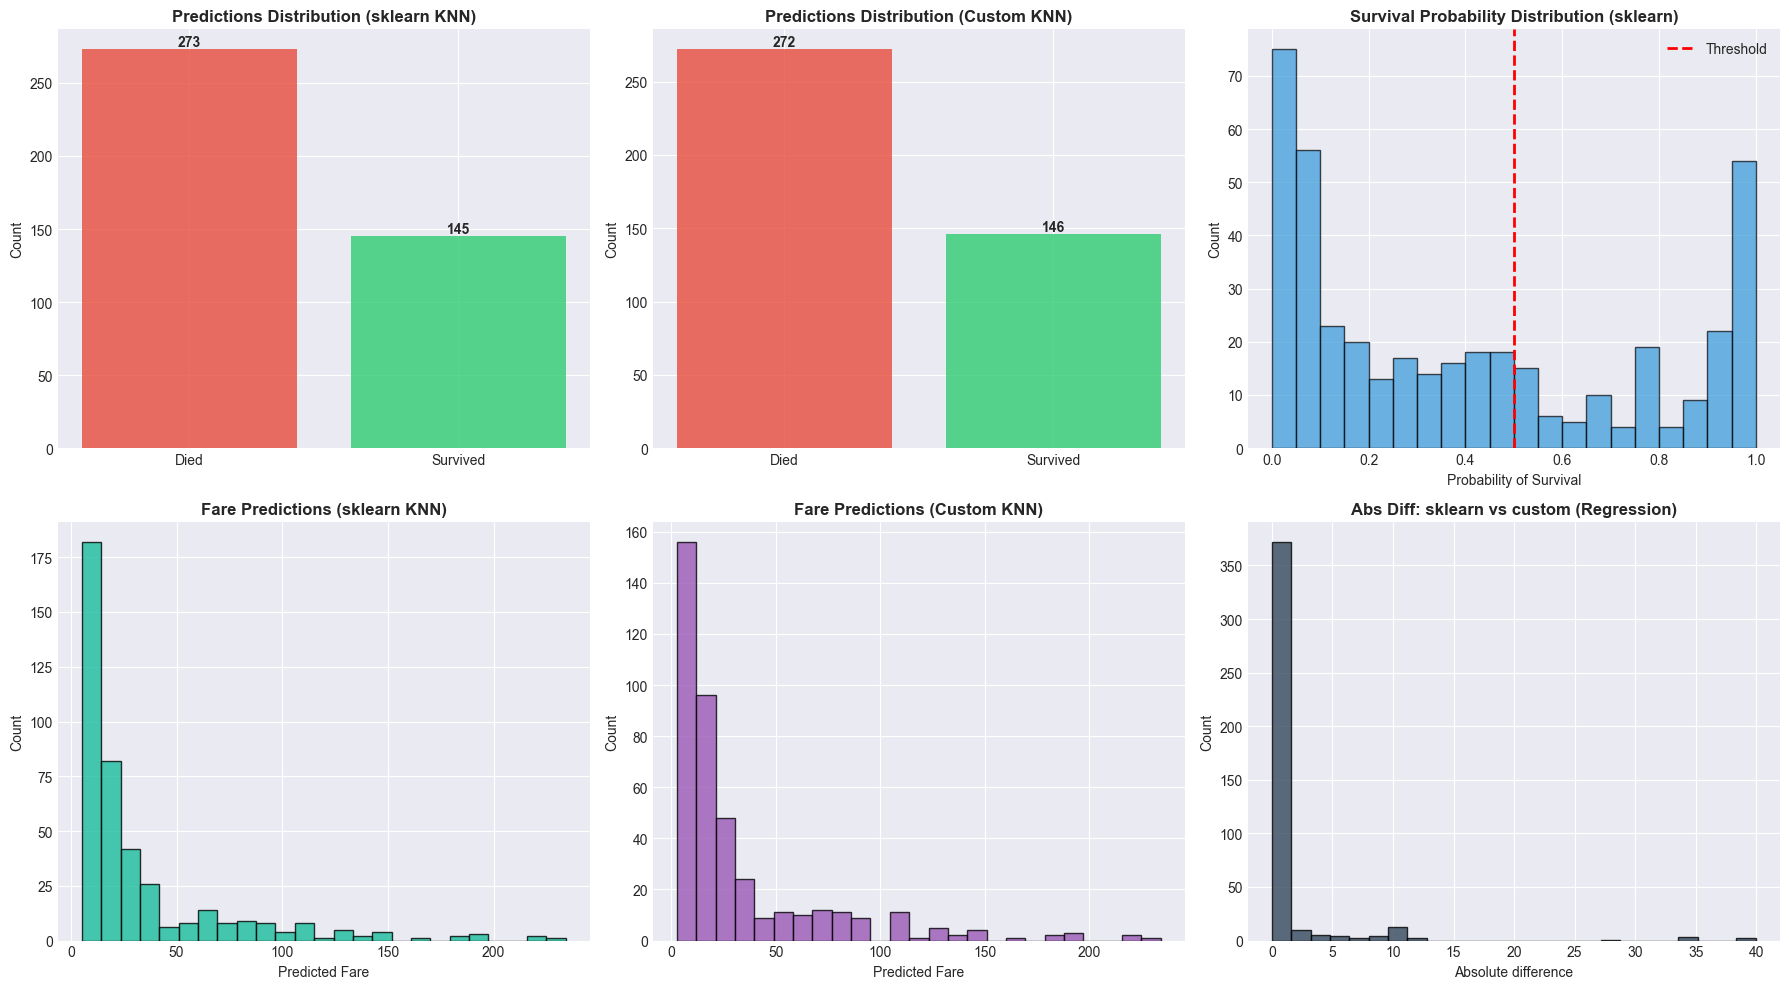

In [44]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

survival_counts_sklearn = pd.Series(predictions_sklearn).value_counts().sort_index()
axes[0,0].bar([0, 1], survival_counts_sklearn.values, color=['#e74c3c', '#2ecc71'], alpha=0.8)
axes[0,0].set_title('Predictions Distribution (sklearn KNN)', fontweight='bold', fontsize=12)
axes[0,0].set_xticks([0, 1])
axes[0,0].set_xticklabels(['Died', 'Survived'])
axes[0,0].set_ylabel('Count')
for i, v in enumerate(survival_counts_sklearn.values):
    axes[0,0].text(i, v, str(v), ha='center', va='bottom', fontweight='bold')

survival_counts_custom = pd.Series(predictions_custom).value_counts().sort_index()
axes[0,1].bar([0, 1], survival_counts_custom.values, color=['#e74c3c', '#2ecc71'], alpha=0.8)
axes[0,1].set_title('Predictions Distribution (Custom KNN)', fontweight='bold', fontsize=12)
axes[0,1].set_xticks([0, 1])
axes[0,1].set_xticklabels(['Died', 'Survived'])
axes[0,1].set_ylabel('Count')
for i, v in enumerate(survival_counts_custom.values):
    axes[0,1].text(i, v, str(v), ha='center', va='bottom', fontweight='bold')

survival_proba = predictions_proba_sklearn[:, 1]
axes[0,2].hist(survival_proba, bins=20, color='#3498db', edgecolor='black', alpha=0.7)
axes[0,2].set_title('Survival Probability Distribution (sklearn)', fontweight='bold', fontsize=12)
axes[0,2].set_xlabel('Probability of Survival')
axes[0,2].set_ylabel('Count')
axes[0,2].axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Threshold')
axes[0,2].legend()

axes[1,0].hist(predictions_reg_sklearn, bins=25, color='#1abc9c', edgecolor='black', alpha=0.8)
axes[1,0].set_title('Fare Predictions (sklearn KNN)', fontweight='bold', fontsize=12)
axes[1,0].set_xlabel('Predicted Fare')
axes[1,0].set_ylabel('Count')

axes[1,1].hist(predictions_reg_custom, bins=25, color='#9b59b6', edgecolor='black', alpha=0.8)
axes[1,1].set_title('Fare Predictions (Custom KNN)', fontweight='bold', fontsize=12)
axes[1,1].set_xlabel('Predicted Fare')
axes[1,1].set_ylabel('Count')

reg_diff = np.abs(predictions_reg_sklearn - predictions_reg_custom)
axes[1,2].hist(reg_diff, bins=25, color='#34495e', edgecolor='black', alpha=0.8)
axes[1,2].set_title('Abs Diff: sklearn vs custom (Regression)', fontweight='bold', fontsize=12)
axes[1,2].set_xlabel('Absolute difference')
axes[1,2].set_ylabel('Count')

plt.tight_layout()
plt.show()


## Анализ уверенности предсказаний

Анализируем вероятности предсказаний (predict_proba) для задачи классификации:
- Распределение вероятностей
- Уверенность модели в предсказаниях
- Выявление сомнительных случаев

Позволяет оценить надёжность модели.

In [45]:
confidence = predictions_proba_sklearn.max(axis=1)

print(f"Средняя уверенность: {confidence.mean():.4f}")
print(f"Минимальная уверенность: {confidence.min():.4f}")
print(f"Максимальная уверенность: {confidence.max():.4f}")

print(f"\nРаспределение уверенности:")
print(f"  Очень уверенные (>0.9): {(confidence > 0.9).sum()} ({(confidence > 0.9).sum() / len(confidence) * 100:.1f}%)")
print(f"  Уверенные (0.7-0.9): {((confidence > 0.7) & (confidence <= 0.9)).sum()} ({((confidence > 0.7) & (confidence <= 0.9)).sum() / len(confidence) * 100:.1f}%)")
print(f"  Неуверенные (<0.7): {(confidence <= 0.7).sum()} ({(confidence <= 0.7).sum() / len(confidence) * 100:.1f}%)")

uncertain_indices = np.where(confidence < 0.6)[0]
if len(uncertain_indices) > 0:
    print(f"Примеры неуверенных предсказаний:")
    for idx in uncertain_indices[:5]:
        print(f"  PassengerId {passenger_ids.iloc[idx]}: Survived={predictions_sklearn[idx]}, Proba={predictions_proba_sklearn[idx]}")


Средняя уверенность: 0.8323
Минимальная уверенность: 0.5000
Максимальная уверенность: 1.0000

Распределение уверенности:
  Очень уверенные (>0.9): 207 (49.5%)
  Уверенные (0.7-0.9): 109 (26.1%)
  Неуверенные (<0.7): 102 (24.4%)
Примеры неуверенных предсказаний:
  PassengerId 896: Survived=0, Proba=[0.56497501 0.43502499]
  PassengerId 903: Survived=0, Proba=[0.59195395 0.40804605]
  PassengerId 915: Survived=0, Proba=[0.51075418 0.48924582]
  PassengerId 920: Survived=1, Proba=[0.47061476 0.52938524]
  PassengerId 924: Survived=1, Proba=[0.49857675 0.50142325]


## Пункт 6: Итоговое сравнение и выводы

### Итоговая сравнительная таблица результатов

Формируем сводную таблицу всех экспериментов:

**Строки**:
- Baseline (sklearn)
- Improved (sklearn)
- Baseline (custom)
- Improved (custom)

**Столбцы**:
- Метрики классификации: Accuracy, Accuracy, Precision, Recall
- Метрики регрессии: RMSE, MAE, R²

Таблица позволяет наглядно оценить эффективность каждого улучшения.

In [46]:
print(f"{'Модель':<40} {'Accuracy':<12} {'Accuracy':<12}")
print(f"{'sklearn baseline (poly+scaled)':<40} {baseline_clf['f1']:<12.4f} {baseline_clf['f1']:<12.4f}")
print(f"{'sklearn improved (Boruta+RFECV)':<40} {improved_clf['f1']:<12.4f} {improved_clf['f1']:<12.4f}")
print(f"{'custom baseline (poly+scaled)':<40} {cv_custom_base_clf.mean():<12.4f} {'-':<12}")
print(f"{'custom improved (Boruta+RFECV)':<40} {custom_improved_clf['f1']:<12.4f} {custom_improved_clf['f1']:<12.4f}")

print(f"{'Модель':<40} {'RMSE':<12} {'R²':<12}")
print(f"{'sklearn baseline (poly+scaled)':<40} {baseline_reg['huber_loss']:<12.4f} {baseline_reg['r2']:<12.4f}")
print(f"{'sklearn improved (Boruta+RFECV)':<40} {improved_reg['huber_loss']:<12.4f} {improved_reg['r2']:<12.4f}")
print(f"{'custom baseline (poly+scaled)':<40} {cv_custom_base_reg.mean():<12.4f} {'-':<12}")
print(f"{'custom improved (Boruta+RFECV)':<40} {custom_improved_reg['huber_loss']:<12.4f} {'-':<12}")

improvement_clf = ((improved_clf['f1'] - baseline_clf['f1']) / baseline_clf['f1'] * 100)
improvement_reg = ((baseline_reg['huber_loss'] - improved_reg['huber_loss']) / baseline_reg['huber_loss'] * 100)


Модель                                   Accuracy     Accuracy    
sklearn baseline (poly+scaled)           0.8193       0.8193      
sklearn improved (Boruta+RFECV)          0.8272       0.8272      
custom baseline (poly+scaled)            0.8171       -           
custom improved (Boruta+RFECV)           0.8294       0.8294      
Модель                                   RMSE         R²          
sklearn baseline (poly+scaled)           18.0481      0.4696      
sklearn improved (Boruta+RFECV)          16.8078      0.4542      
custom baseline (poly+scaled)            18.6495      -           
custom improved (Boruta+RFECV)           17.4558      -           


## Визуализация сравнения моделей

Строим bar charts для наглядного сравнения:
- **Левый график**: Accuracy для классификации
- **Правый график**: RMSE для регрессии

Визуализация показывает:
- Насколько улучшения превосходят baseline
- Насколько близки результаты sklearn и custom реализаций

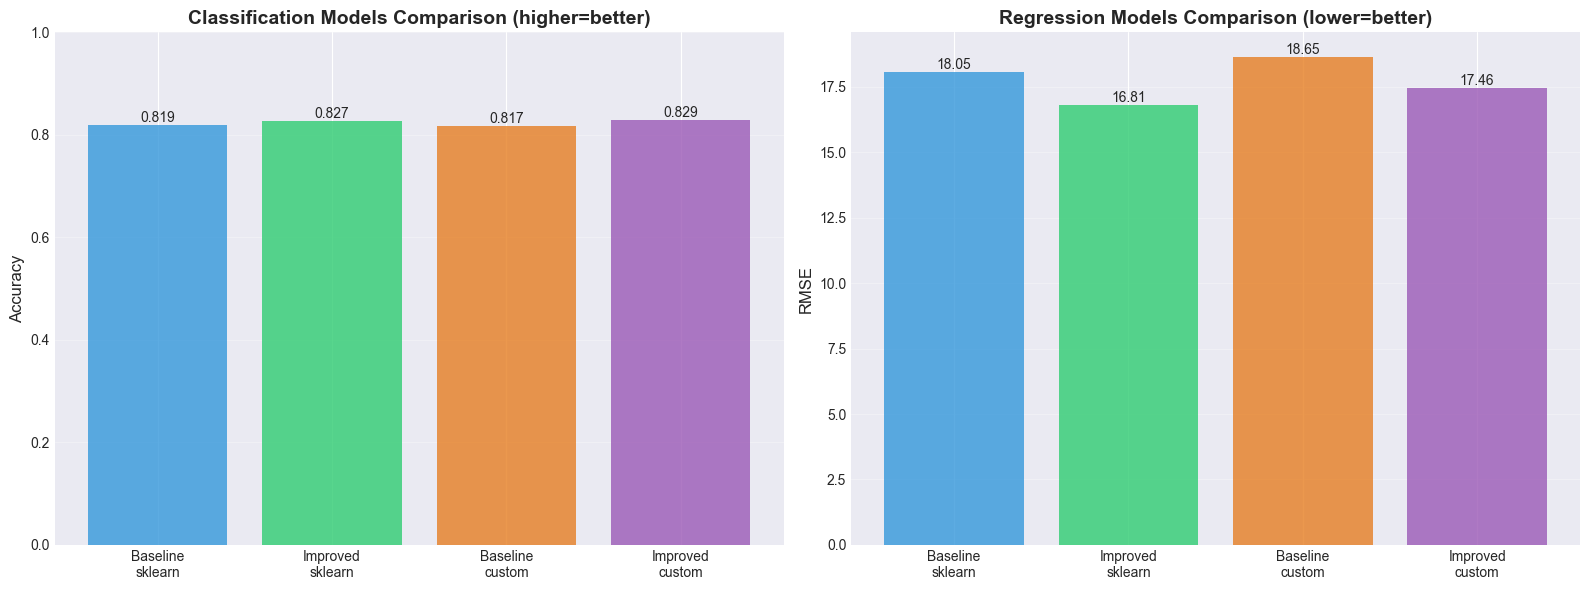

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

models_clf = ['Baseline\nsklearn', 'Improved\nsklearn', 'Baseline\ncustom', 'Improved\ncustom']
accuracy_scores = [baseline_clf['f1'], improved_clf['f1'],
                   cv_custom_base_clf.mean(), custom_improved_clf['f1']]

x = np.arange(len(models_clf))
bars1 = axes[0].bar(x, accuracy_scores, color=['#3498db', '#2ecc71', '#e67e22', '#9b59b6'], alpha=0.8)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Classification Models Comparison (higher=better)', fontweight='bold', fontsize=14)
axes[0].set_xticks(x)
axes[0].set_xticklabels(models_clf)
axes[0].set_ylim([0, 1])
axes[0].grid(True, alpha=0.3, axis='y')

for bar in bars1:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10)

models_reg = ['Baseline\nsklearn', 'Improved\nsklearn', 'Baseline\ncustom', 'Improved\ncustom']
rmse_scores = [baseline_reg['huber_loss'], improved_reg['huber_loss'],
               cv_custom_base_reg.mean(), custom_improved_reg['huber_loss']]

bars2 = axes[1].bar(x, rmse_scores, color=['#3498db', '#2ecc71', '#e67e22', '#9b59b6'], alpha=0.8)
axes[1].set_ylabel('RMSE', fontsize=12)
axes[1].set_title('Regression Models Comparison (lower=better)', fontweight='bold', fontsize=14)
axes[1].set_xticks(x)
axes[1].set_xticklabels(models_reg)
axes[1].grid(True, alpha=0.3, axis='y')

for bar in bars2:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


## Визуализация истории оптимизации Optuna

Графики показывают процесс оптимизации для каждого study:
1. **Scaler (Classification)**: поиск оптимального scaler'а
2. **Scaler (Regression)**: то же для регрессии
3. **Full (Classification)**: полная оптимизация KNN+RFECV
4. **Full (Regression)**: то же для регрессии

**Красная линия**: лучшее найденное значение

Помогает оценить:
- Сходимость оптимизации
- Достаточность количества trials
- Стабильность результатов

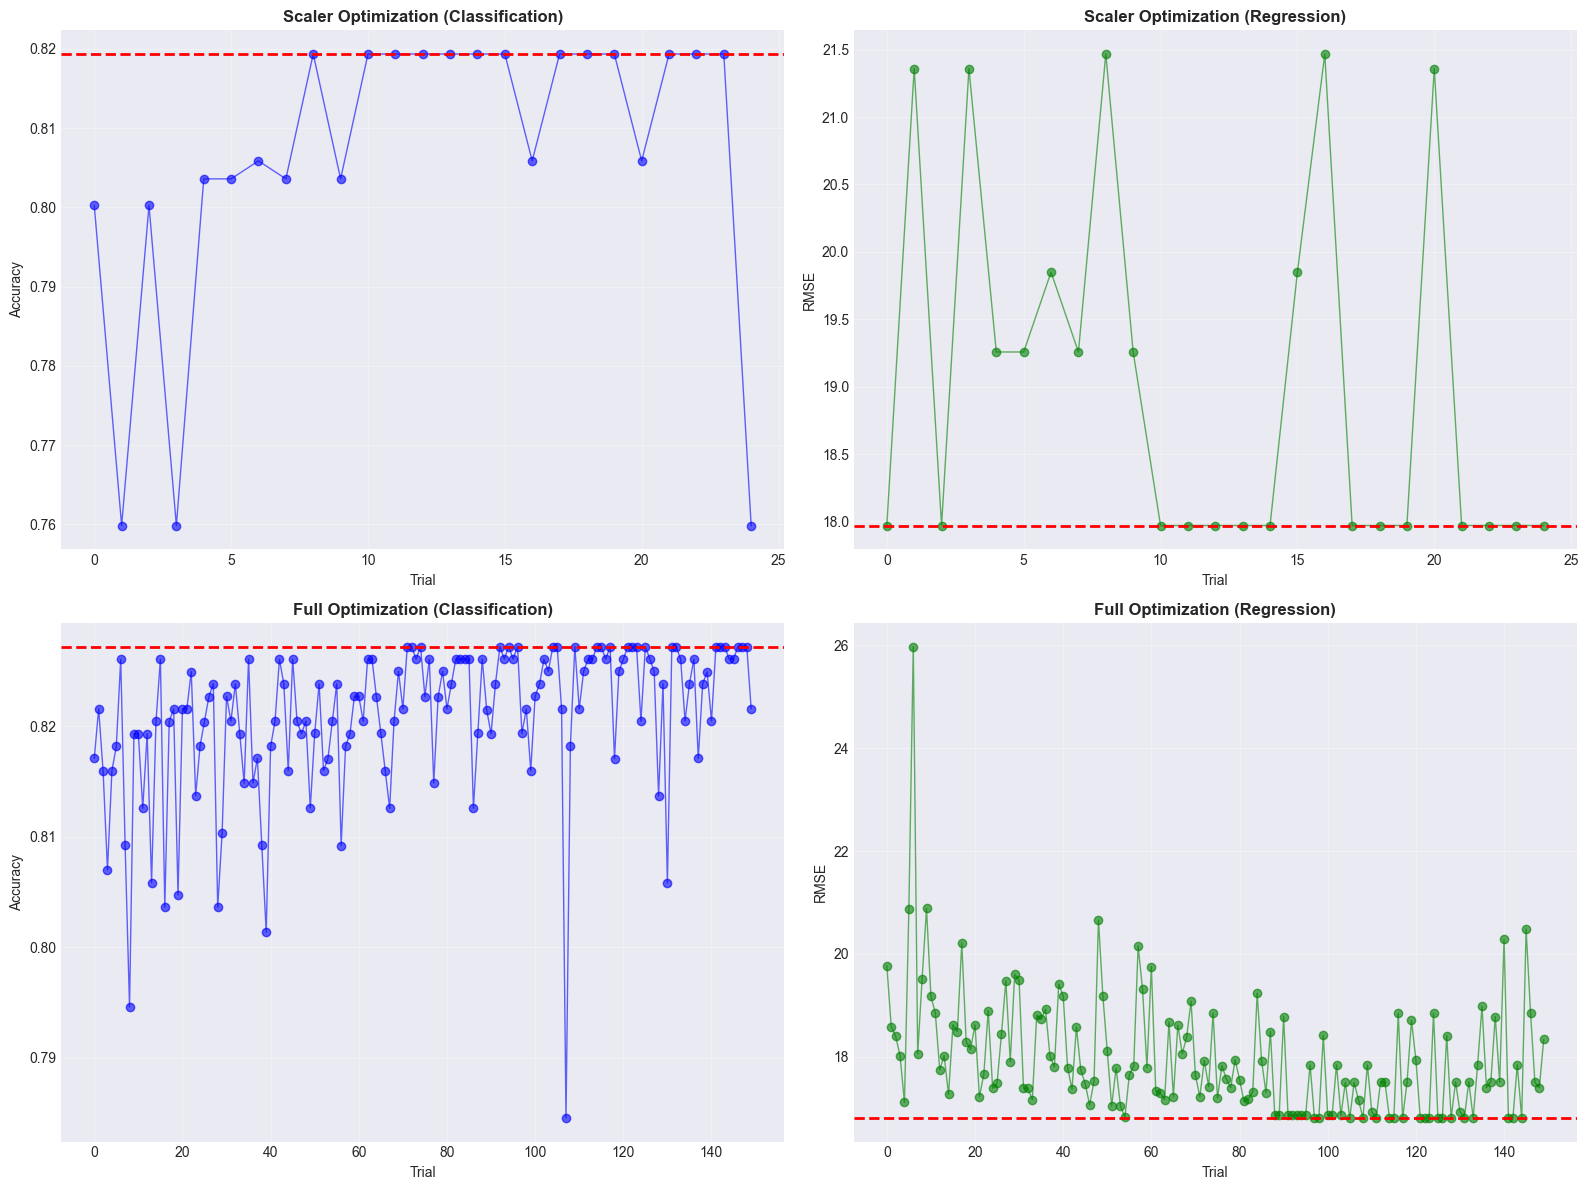

In [48]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

trials_scaler_clf = study_scaler_clf.trials_dataframe()
axes[0,0].plot(trials_scaler_clf['number'], trials_scaler_clf['value'],
               marker='o', alpha=0.6, linewidth=1, color='blue')
axes[0,0].axhline(y=study_scaler_clf.best_value, color='red', linestyle='--', linewidth=2)
axes[0,0].set_title('Scaler Optimization (Classification)', fontweight='bold')
axes[0,0].set_xlabel('Trial')
axes[0,0].set_ylabel('Accuracy')
axes[0,0].grid(True, alpha=0.3)

trials_scaler_reg = study_scaler_reg.trials_dataframe()
axes[0,1].plot(trials_scaler_reg['number'], trials_scaler_reg['value'],
               marker='o', alpha=0.6, linewidth=1, color='green')
axes[0,1].axhline(y=study_scaler_reg.best_value, color='red', linestyle='--', linewidth=2)
axes[0,1].set_title('Scaler Optimization (Regression)', fontweight='bold')
axes[0,1].set_xlabel('Trial')
axes[0,1].set_ylabel('RMSE')
axes[0,1].grid(True, alpha=0.3)

trials_full_clf = study_full_clf.trials_dataframe()
axes[1,0].plot(trials_full_clf['number'], trials_full_clf['value'],
               marker='o', alpha=0.6, linewidth=1, color='blue')
axes[1,0].axhline(y=study_full_clf.best_value, color='red', linestyle='--', linewidth=2)
axes[1,0].set_title('Full Optimization (Classification)', fontweight='bold')
axes[1,0].set_xlabel('Trial')
axes[1,0].set_ylabel('Accuracy')
axes[1,0].grid(True, alpha=0.3)

trials_full_reg = study_full_reg.trials_dataframe()
axes[1,1].plot(trials_full_reg['number'], trials_full_reg['value'],
               marker='o', alpha=0.6, linewidth=1, color='green')
axes[1,1].axhline(y=study_full_reg.best_value, color='red', linestyle='--', linewidth=2)
axes[1,1].set_title('Full Optimization (Regression)', fontweight='bold')
axes[1,1].set_xlabel('Trial')
axes[1,1].set_ylabel('RMSE')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
